<a href="https://colab.research.google.com/github/elettra-ven/DIA-Ventura-SolAq/blob/main/SolAq_DIA_Ventura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predizione della Solubilita Acquosa di Molecole Organiche**

**Programmazione di Applicazioni Data Intensive**

Ventura Elettra - 0001117272

a.a. 2025/2026


##Contesto
La **solubilità di una molecola** è una proprietà chimico-fisica fondamentale in molteplici settori di ricerca.
Conoscere la solubilità di un composto prima ancora di sintetizzarlo in laboratorio consente di ottimizzare i tempi e ridurre drasticamente i costi sperimentali.

Tuttavia, la misurazione sperimentale della solubilità è un processo lungo, costoso e spesso soggetto a variabilità dovuta alle diverse condizioni di laboratorio.

##Obiettivo
Il progetto ha come obiettivo la **predizione della solubilità acquosa** ($LogS$) di molecole organiche, a partire dalle loro proprieta fisicochimiche strutturali, utilizzando tecniche di machine learning supervisato.

##**0. Import librerie**

In [6]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

#**1. Descrizione del Dataset**
## 1.1 Introduzione al problema

La **solubilita acquosa** è una proprieta fondamentale per lo studio bioinformatico delle molecole.

La solubilita e espressa come $LogS$ (log10 della solubilita in mol/L):
- `LogS >= 0` $→$ altamente solubile
- `-2 <= LogS < 0` $→$ solubile
- `-4 <= LogS < -2` $→$ poco solubile
- `LogS < -4` $→$ insolubile

## 1.2 Dataset e fonti

**AqSolDB** (Kaggle:https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) è stato pubblicato da Sorkun et al. su *Scientific Data* nel 2019.

È costruito fondendo **9 dataset sperimentali** con un algoritmo di curation che seleziona il valore piu affidabile.
- **Dimensione:** 9.982 molecole uniche
- **Target:** LogS - valore sperimentale di solubilita acquosa

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sorkun/aqsoldb-a-curated-aqueous-solubility-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.39M/1.39M [00:00<00:00, 119MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset/versions/1


In [76]:
df_init = pd.read_csv(os.path.join(path, "curated-solubility-dataset.csv"))
print("Righe: ",df_init.shape[0])
print("Colonne: ",df_init.shape[1])
df_init.head()

Righe:  9982
Colonne:  26


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,3.9581,102.4454,23.0,0.0,0.0,2.0,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,2.4055,51.9012,13.0,1.0,1.0,2.0,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,2.1525,36.8395,9.0,1.0,0.0,2.0,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,8.1161,200.7106,53.0,6.0,2.0,7.0,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,2.4854,119.0760,31.0,6.0,0.0,6.0,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


##1.3 Descrizione delle variabili

Il dataset contiene le seguenti variabili:

1. **`ID`** *(stringa)*: Identificatore univoco della molecola.
2. **`Name`** *(stringa)*: Nome IUPAC ufficiale della struttura chimica.
3. **`InChI`** *(stringa)*: Rappresentazione chimica internazionale standard.
4. **`InChIKey`** *(stringa)*: Hash compatto a lunghezza fissa della struttura InChI.
5. **`SMILES`** *(stringa)*: Notazione lineare *machine readable* utilizzata per descrivere la struttura molecolare.
6. **`Solubility`** *(float)*: **TARGET** LogS = log10 della solubilità espressa in mol/L.
7. **`SD`** *(float)*: Deviazione standard.
8. **`Occurrences`** *(int)*: Numero di dataset originali in cui compare la molecola.
9. **`Group`** *(stringa)*: Etichetta di affidabilità della misurazione effettuata (meta-dato).
10. **`MolWt`** *(float)*: Peso molecolare complessivo espresso in Dalton.
11. **`MolLogP`** *(float)*: Lipofilia, ovvero affinità per i grassi rispetto all'acqua.
12. **`MolMR`** *(float)*: Rifrazione molare, ovvero misura della polarizzabilità globale della molecola.
13. **`TPSA`** *(float)*: Superficie polare topologica, ovvero area delle regioni polari molecolari.
14. **`LabuteASA`** *(float)*: Area di superficie molecolare accessibile al solvente calcolata secondo il modello di Labute.
15. **`HeavyAtomCount`** *(int)*: Numero di atomi non-idrogeno ("pesanti") presenti nel sistema.
16. **`NumHAcceptors`** *(int)*: Accettori di legami idrogeno.
17. **`NumHDonors`** *(int)*: Donatori di legami idrogeno.
18. **`NumHeteroatoms`** *(int)*: Numero di eteroatomi (atomi diversi da Carbonio e Idrogeno) nel nucleo molecolare.
19. **`NumRotatableBonds`** *(int)*: Legami ruotabili, ovvero indice della flessibilità di rotazione della struttura.
20. **`NumValenceElectrons`** *(int)*: Numero complessivo di elettroni di valenza.
21. **`NumAromaticRings`** *(int)*: Numero di anelli aromatici presenti.
22. **`NumSaturatedRings`** *(int)*: Numero di anelli completamente saturi.
23. **`NumAliphaticRings`** *(int)*: Numero totale di anelli alifatici presenti.
24. **`RingCount`** *(int)*: Numero totale di anelli.
25. **`BalabanJ`** *(float)*: Indice di connettività topologica di Balaban.
26. **`BertzCT`** *(float)*: Indice topologico di Bertz per la quantificazione della complessità strutturale.

##1.4 Prima scrematura dei dati
Rimuoviamo le colonne che non contengono informazioni predittive ("meta-dati" e identificatori):
- `ID`, `Name`, `InChI`, `InChIKey`, `SMILES`: sono tutti **identificatori** e non portano particolari informazioni sulla struttura
- `SD`: **deviazione standard** delle misurazioni effettuate da diverse fonti
- `Occurrences`: numero di occorrenze di un composto
- `Group`: etichetta meta-dato per l'affidabilità

In [9]:
# Individuo le colonne da rimuovere
cols_to_drop = ["ID", "Name", "InChI", "InChIKey", "SMILES",
                "SD", "Ocurrences", "Group"]

df = df_init.drop(columns=cols_to_drop)

print("Righe dopo scrematura: ",df.shape[0])
print("Colonne dopo scrematura: ",df.shape[1])

Righe dopo scrematura:  9982
Colonne dopo scrematura:  18


In [10]:
print("Tipi di dati: ", df.dtypes.to_string())

Tipi di dati:  Solubility             float64
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount         float64
NumHAcceptors          float64
NumHDonors             float64
NumHeteroatoms         float64
NumRotatableBonds      float64
NumValenceElectrons    float64
NumAromaticRings       float64
NumSaturatedRings      float64
NumAliphaticRings      float64
RingCount              float64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64


Rimangono 18 variabili nel dataset, di queste:
- 1 è il target
- 7 sono variabili **continue** (*float*)
- 10 sono variabili che, secondo le indicazione del dataset, rappresentano conteggi **discreti**

Ma come abbiamo notato, i dati sono stati caricati tutti come `float64`.
Effettuiamo la conversione per mantenere consistenza semantica nella differenziazione tra viariabili **discrete** e **continue**.

In [11]:
features_discrete = [
    'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings',
    'NumSaturatedRings', 'NumAliphaticRings', 'RingCount'
]
df[features_discrete] = df[features_discrete].astype('int64')

print("Nuova verifica dei tipi di dato:")
print(df.dtypes.to_string())

Nuova verifica dei tipi di dato:
Solubility             float64
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount           int64
NumHAcceptors            int64
NumHDonors               int64
NumHeteroatoms           int64
NumRotatableBonds        int64
NumValenceElectrons      int64
NumAromaticRings         int64
NumSaturatedRings        int64
NumAliphaticRings        int64
RingCount                int64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64


#**2. Analisi Esplorativa del Dataset (EDA)**


##2.1 Statistiche descrittive


In [148]:
df.describe().round(3)

,Solubility,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000,9982.000
mean,-2.890,266.666,1.979,66.795,17.375,3.487,1.109,5.197,4.073,94.243,1.068,0.293,0.448,1.516,62.459,108.913,2.392,467.337
std,2.368,184.179,3.518,46.523,12.242,3.498,1.489,4.736,5.647,64.749,1.309,0.880,1.055,1.644,63.348,76.463,1.091,546.632
min,-13.172,9.012,-40.873,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,7.504,-0.000,0.000
25%,-4.326,162.276,0.620,40.602,11.000,2.000,0.000,3.000,1.000,58.000,0.000,0.000,0.000,0.000,26.300,66.624,2.004,163.243
50%,-2.618,228.682,1.949,58.633,15.000,3.000,1.000,4.000,3.000,82.000,1.000,0.000,0.000,1.000,50.720,93.300,2.540,351.640
75%,-1.210,320.436,3.419,81.938,21.000,4.000,2.000,6.000,5.000,112.000,2.000,0.000,1.000,2.000,80.390,129.118,3.032,606.563
max,2.138,5299.456,68.541,1419.352,388.000,86.000,26.000,89.000,141.000,2012.000,35.000,30.000,30.000,36.000,1214.340,2230.685,7.517,20720.268


Dall'analisi delle statistiche descrittive emerge una marcata eterogeneità nel dataset, testimoniata da range di valore estremamente ampi. In particolare, il confronto tra media e massimo per variabili come MolWt (Peso Molecolare) e BertzCT (Complessità Strutturale) evidenzia la presenza di molecole di dimensioni molto grandi che si discostano significativamente dalla maggior parte dei composti. Parallelamente, i valori estremi riscontrati in MolLogP (con un minimo di $-40.87$ e un massimo di $+68.54$) confermano la presenza di anomalie strutturali e fisiche.

##2.2 Verifica dei Valori Nulli (NaN)

In [13]:
nan_counts = df.isna().sum()
if nan_counts.sum() == 0:
  print("Non ci sono valori nulli nel dataset.")
else:
  print("Valori nulli per colonna:", nan_counts[nan_counts>0])

Non ci sono valori nulli nel dataset.


Il dataset è privo di valori NaN, quindi non è necessario sostituirli o eliminarli.

##2.3 Distribuzione del Target (solubilità LogS)
Analizziamo la distribuzione della variabile target tramite **istogramma** e **box plot**.

In [14]:
solubility_data = df["Solubility"]
mean_sol = solubility_data.mean()
median_sol = solubility_data.median()

sol_class_labels = [
    "Insolubile (LogS < -4)",
    "Poco sol. (-4, -2]",
    "Solubile (-2, 0]",
    "Molto sol. (> 0)"
]

classi_sol = pd.cut(
    solubility_data,
    bins=[-float("inf"), -4, -2, 0, float("inf")],
    labels=sol_class_labels
)

print("Metriche calcolate.")

Metriche calcolate.


In [15]:
print("Distribuzione per classe di solubilità:")
df_classi = classi_sol.value_counts().sort_index().to_frame(name="")
display(df_classi)

print(f"\nMedia: {df['Solubility'].mean():.3f}")
print(f"Mediana: {df['Solubility'].median():.3f}")
print(f"Min: {df['Solubility'].min():.3f}")
print(f"Max: {df['Solubility'].max():.3f}")

Distribuzione per classe di solubilità:


,
Solubility,
Insolubile (LogS < -4),2879
"Poco sol. (-4, -2]",3207
"Solubile (-2, 0]",2840
Molto sol. (> 0),1056



Media: -2.890
Mediana: -2.618
Min: -13.172
Max: 2.138


Possiamo notare che i valori di **media** e **mediana** sono tra loro abbastanza vicine, dando alla variabile una distribuzione **lievemente simmetrica**.

La classe più frequente è "**Poco solubile**", con valori tra -4 e -2.

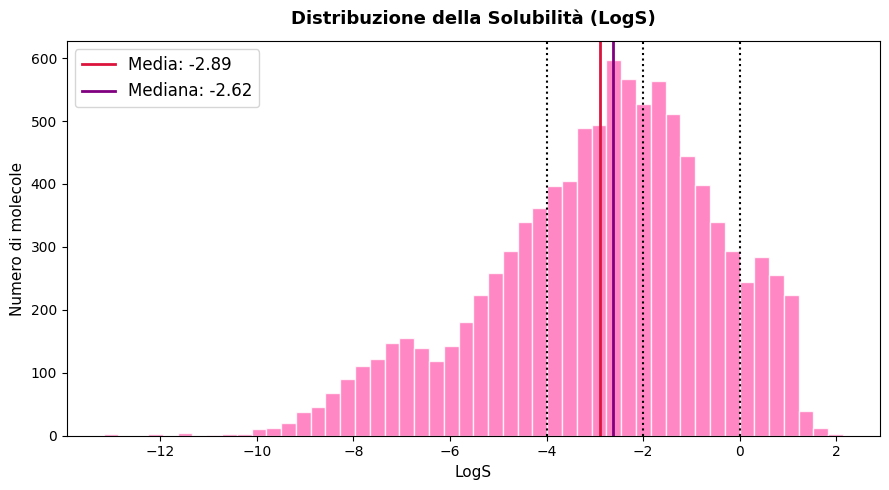

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(solubility_data, bins=50, color="hotpink", edgecolor="white", alpha=0.8)
plt.axvline(mean_sol, color="crimson", linestyle="-", linewidth=2, label=f"Media: {mean_sol:.2f}")
plt.axvline(median_sol, color="purple", linestyle="-", linewidth=2, label=f"Mediana: {median_sol:.2f}")

soglie = [-4,-2,0]
for soglia in soglie:
    plt.axvline(soglia, color="black", linestyle=":", linewidth=1.5)

plt.title("Distribuzione della Solubilità (LogS)", fontsize=13, pad=12, fontweight='bold')
plt.xlabel("LogS", fontsize=11)
plt.ylabel("Numero di molecole", fontsize=11)
plt.legend(loc="upper left", frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

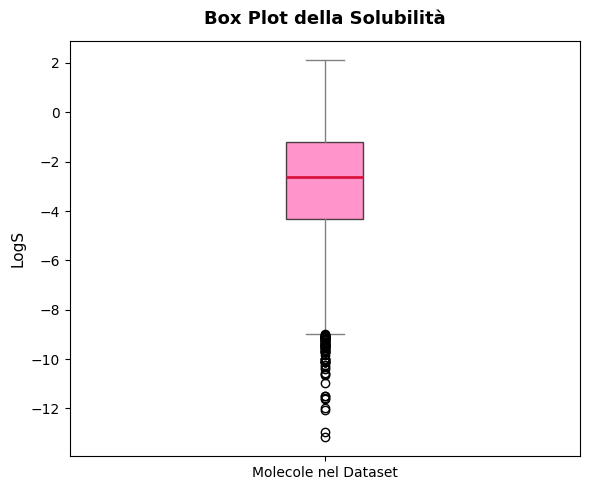

In [17]:
plt.figure(figsize=(6, 5))

plt.boxplot(
    solubility_data,
    patch_artist=True,
    boxprops=dict(facecolor="hotpink", alpha=0.7, edgecolor="black"),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray")
)

plt.title("Box Plot della Solubilità", fontsize=13, pad=12, fontweight='bold')
plt.xticks([1], ["Molecole nel Dataset"])

plt.ylabel("LogS", fontsize=11)

plt.tight_layout()
plt.show()

Il grafico a barre mostra una distribuzione semi-normale, centrata intorno ai valori di media e mediana (che hanno tra loro minima discrepanza).

Notiamo un'asimmetria nella forma di una "coda sinistra" più pronunciata nell'istogramma e degli outlier evidenti nel box-plot, che riflettono la presenza di composti assolutamente insolubili ($LogS < -8$) ma reali ed esistenti in natura.

##2.4 Distribuzione delle Feature
L'obiettivo di questa analisi è capire se le distribuzioni dei predittori presentano asimmetrie, bassa varianza, valori anomali e/o numerosi zeri, per poter poi lavorare sulle correlazioni.

###2.4.1 Feature continue

In [18]:
features_continuous = [
    'MolWt', 'MolLogP', 'MolMR', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT'
]

In [19]:
def plot_features_his(features, title):
    num_feat = len(features)
    if num_feat == 0:
        print("Nessuna feature fornita.")
        return

    n_cols = 2
    n_rows = (num_feat + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

    if num_feat == 1:
        axes_flat = np.array([axes])
    else:
        axes_flat = axes.ravel()

    for i, col in enumerate(features):
        ax = axes_flat[i]
        ax.hist(df[col], bins=50, color="hotpink", edgecolor="white", alpha=0.75)

        mean_val = df[col].mean()
        ax.axvline(mean_val, color="crimson", linestyle="--", linewidth=1.5,
                   label=f"Media: {mean_val:.2f}")

        ax.set_title(col, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("Valore", fontsize=12)
        ax.set_ylabel("Frequenza", fontsize=12)
        ax.tick_params(labelsize=11)
        ax.legend(fontsize=11, loc="upper right")

    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.suptitle(title, fontsize=18, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

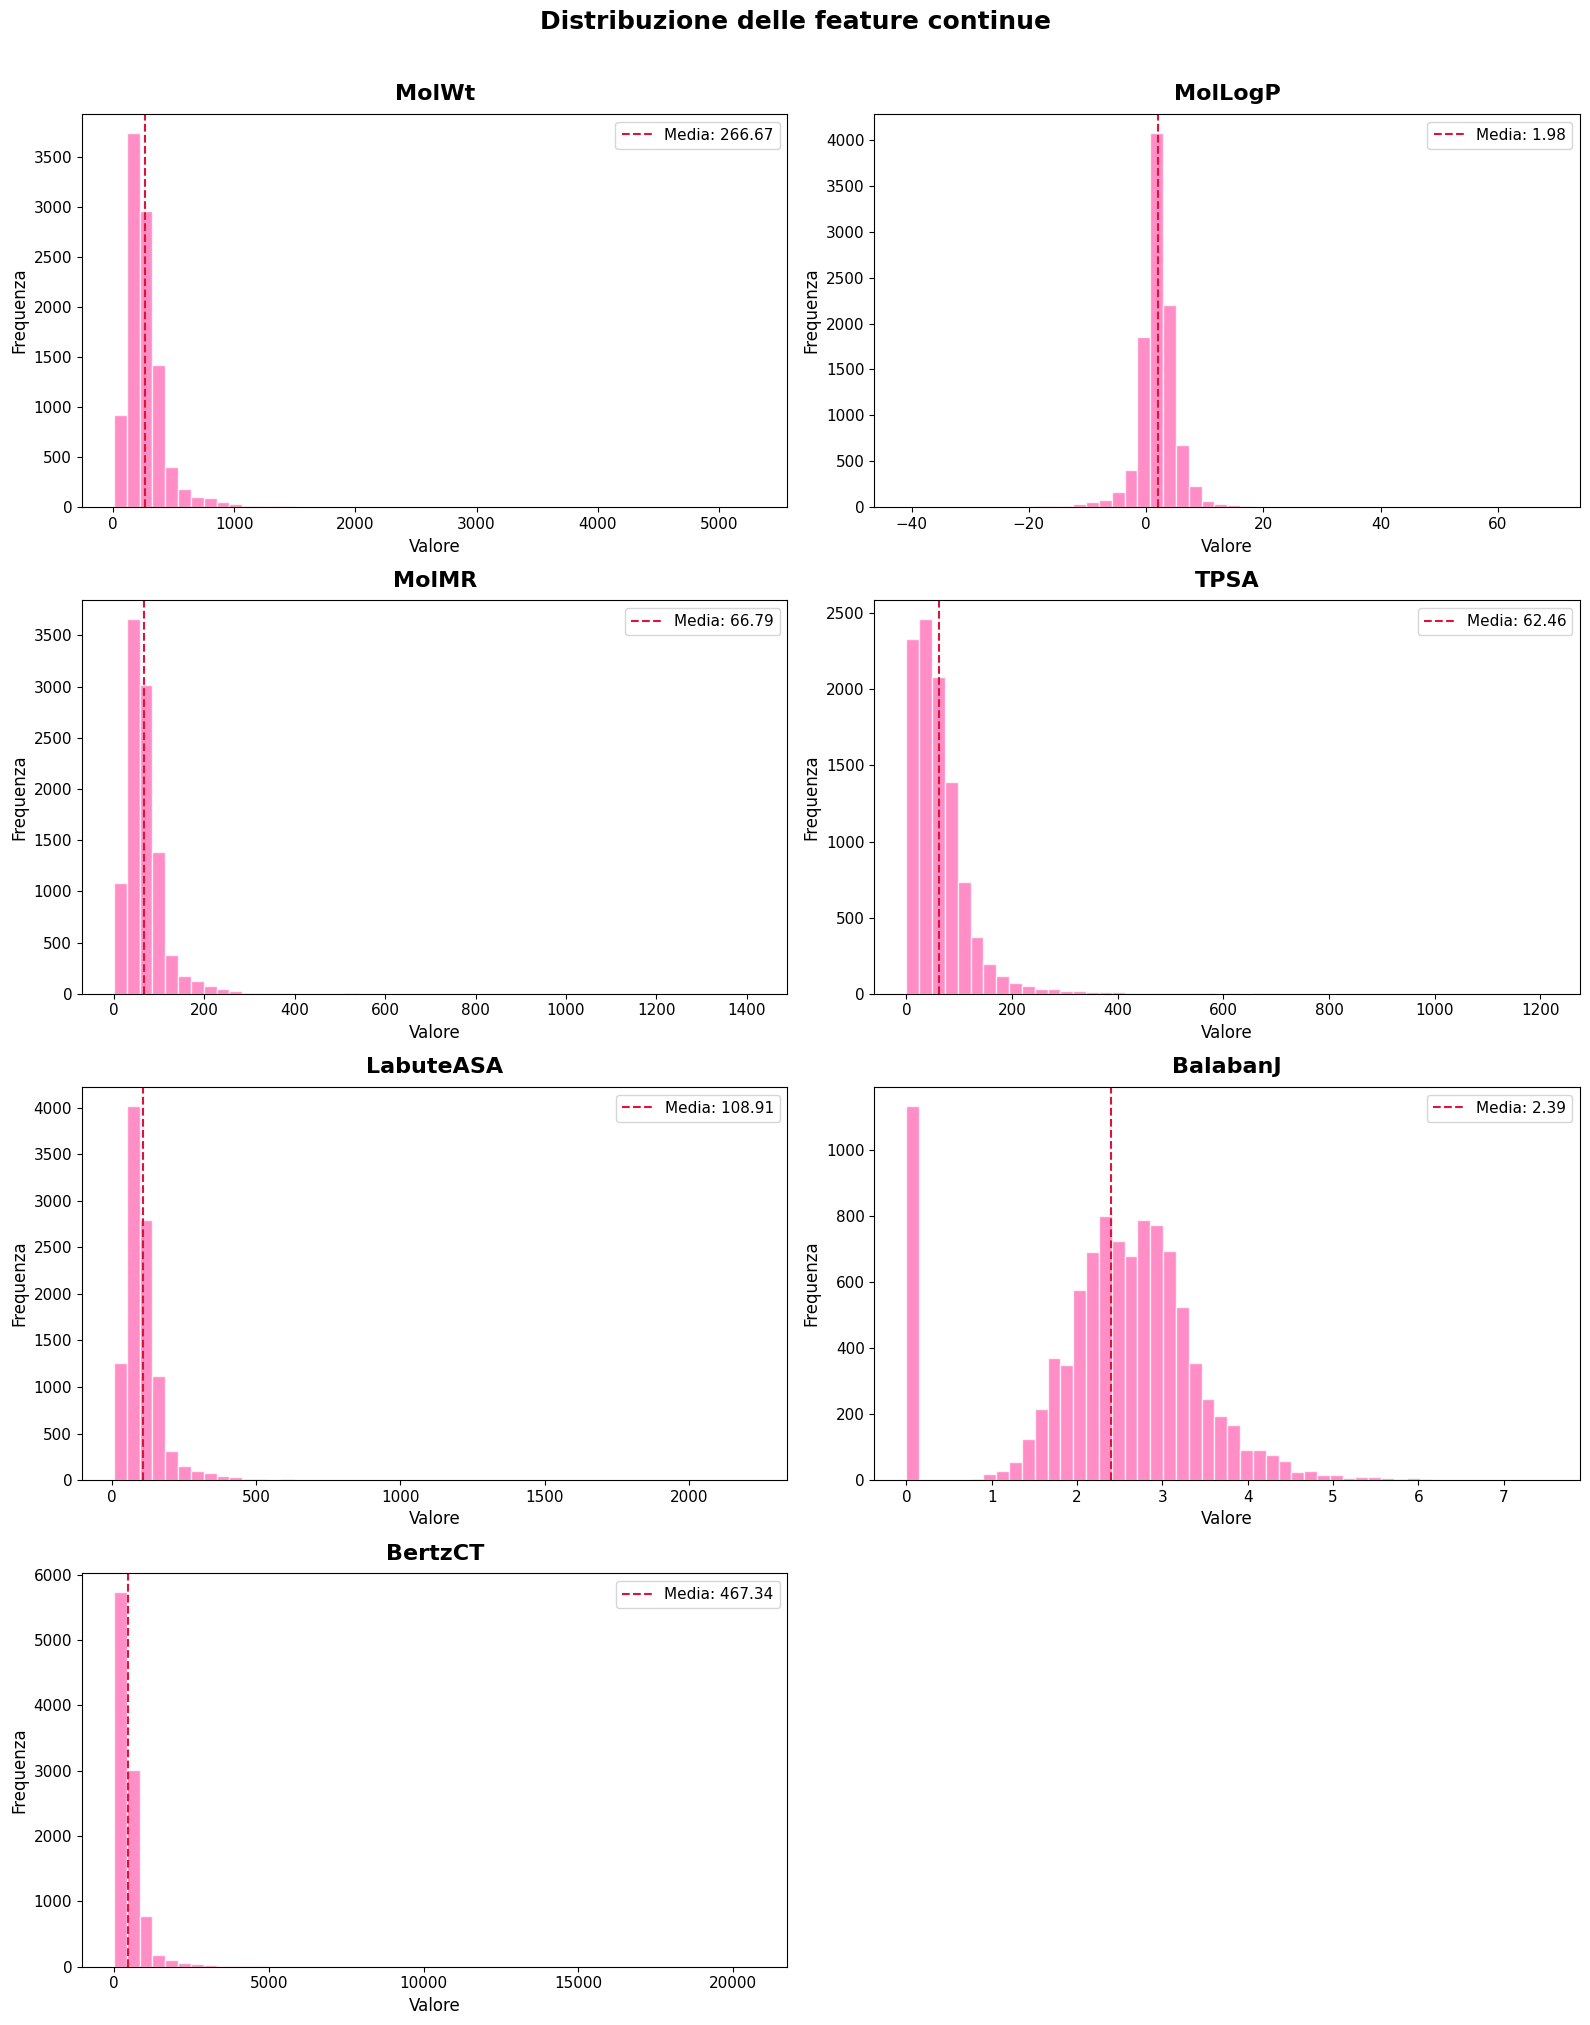

In [20]:
plot_features_his(features_continuous, "Distribuzione delle feature continue")

###2.4.2 Feature discrete

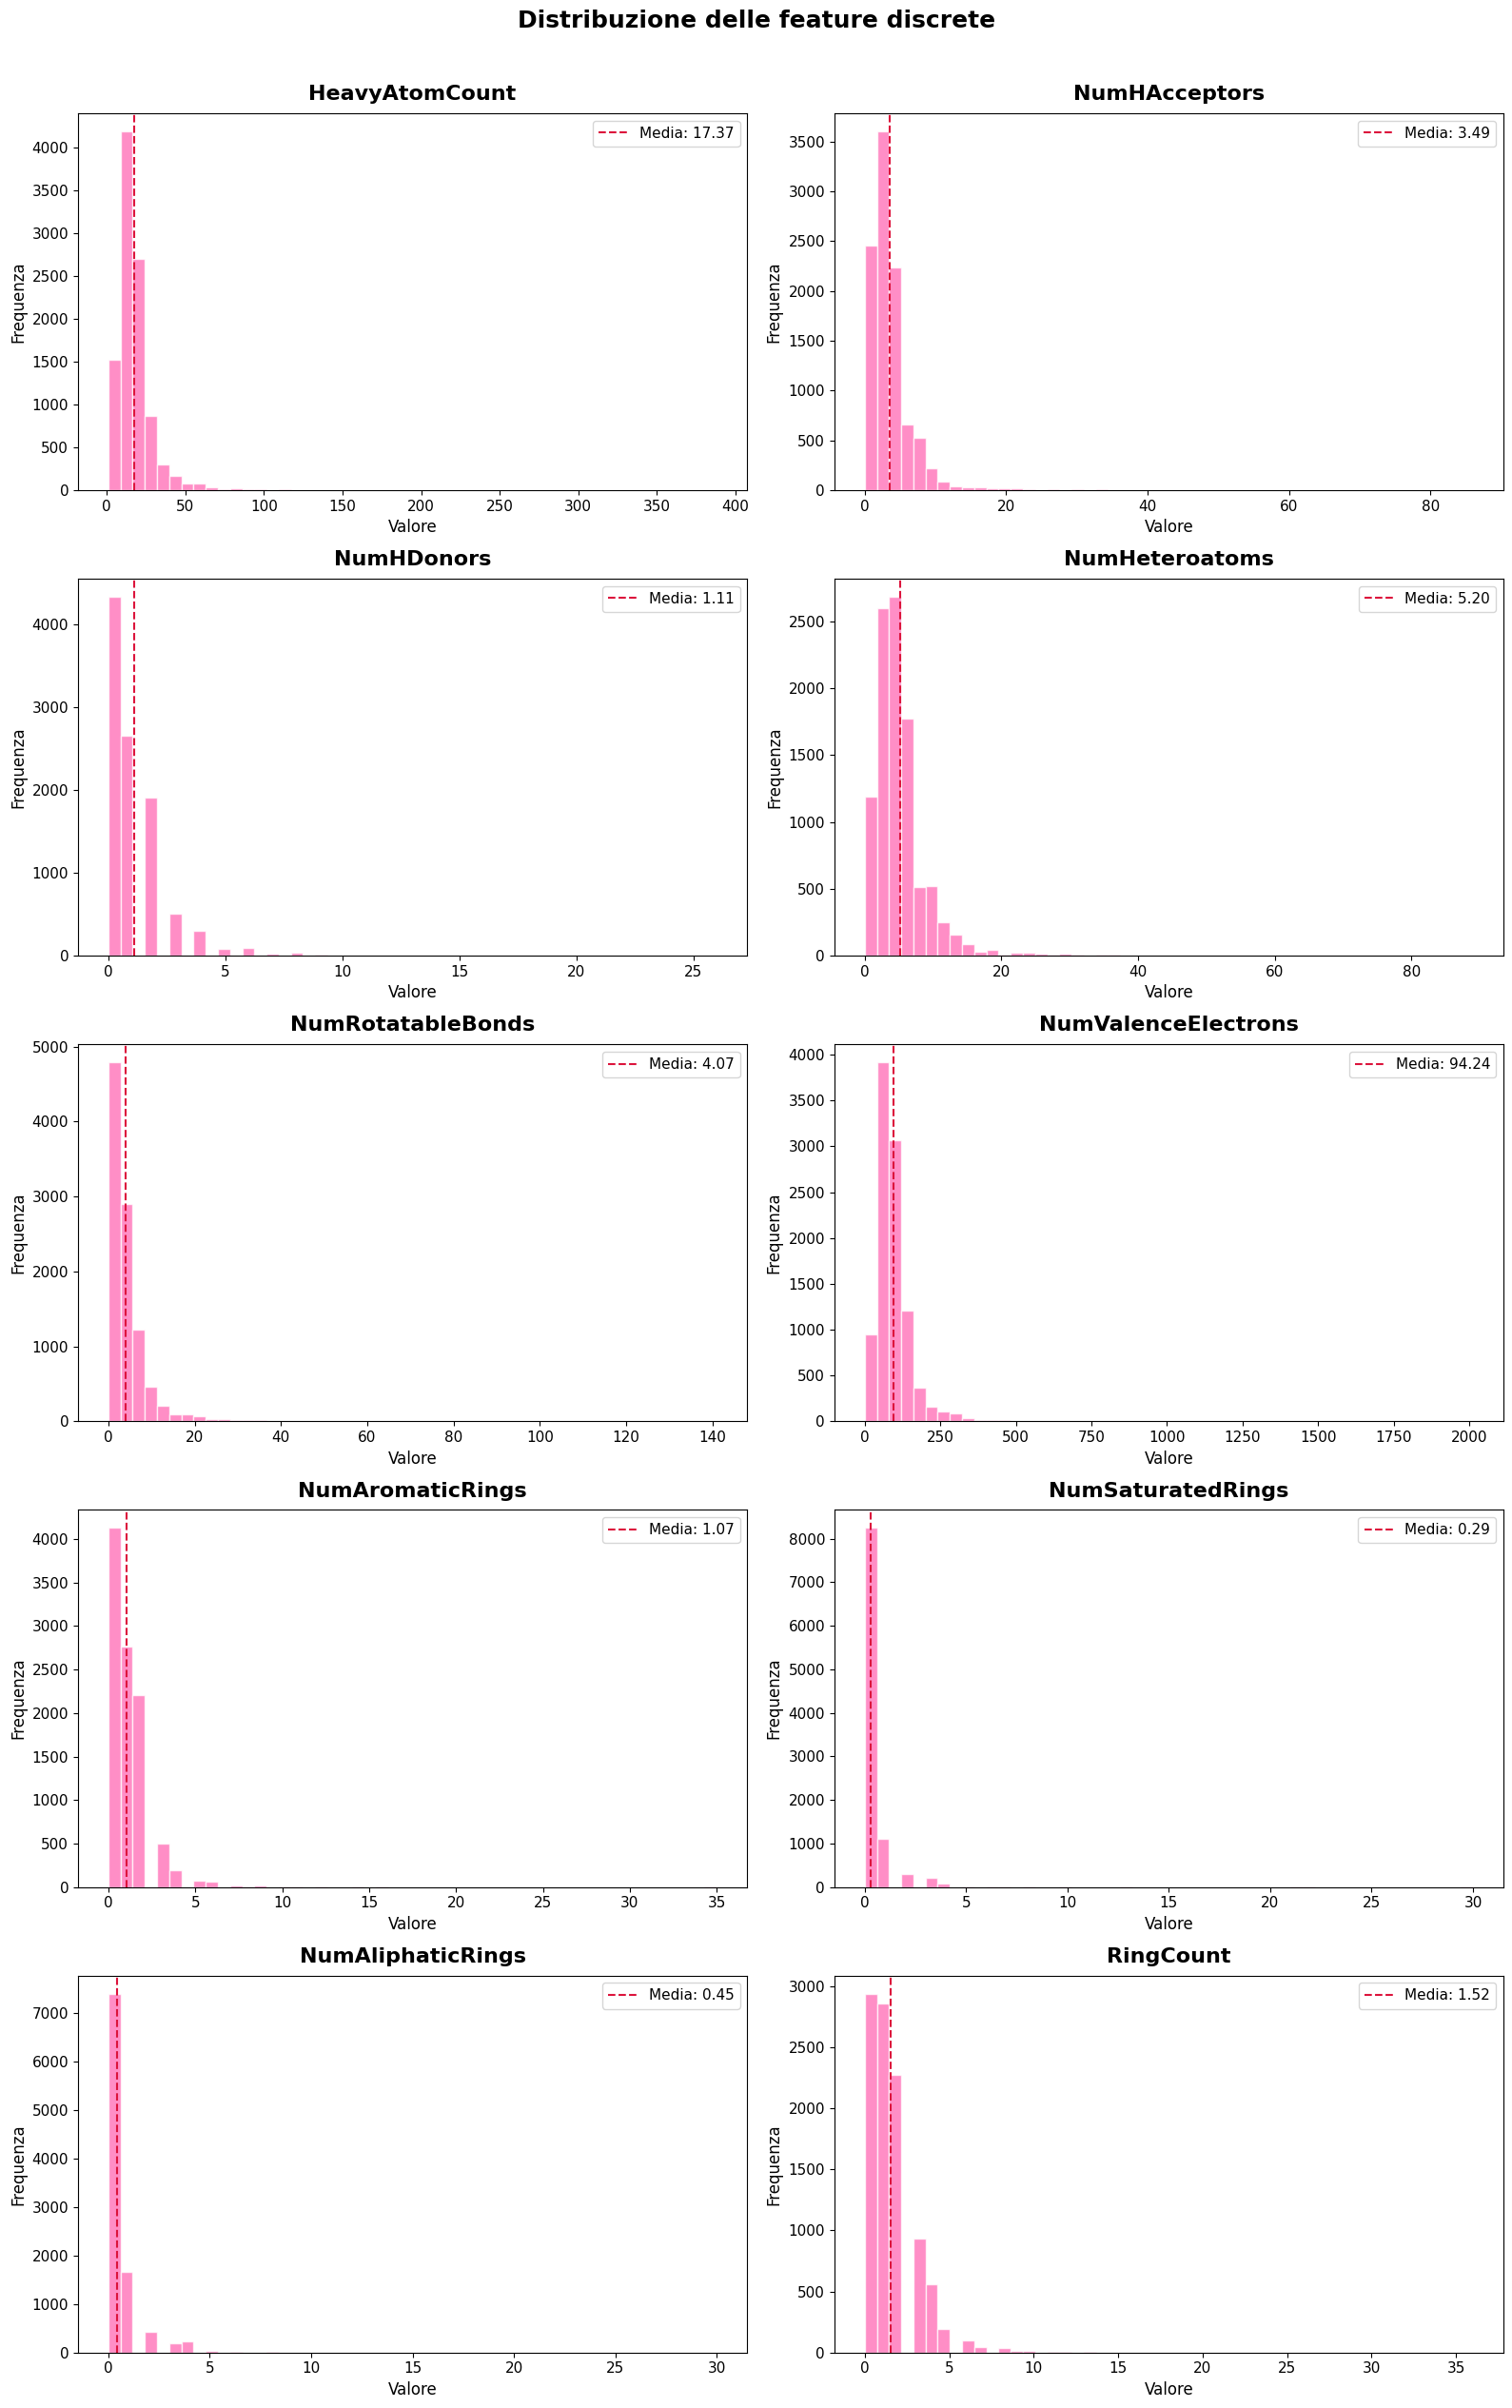

In [21]:
plot_features_his(features_discrete, "Distribuzione delle feature discrete")

Come visibile dagli istogrammi, molte feature presentano asimmetrie con code sbilanciate.

Questo renderà necessario analizzare attentamente gli **outliers** nel prossimo step dell'analisi.

###2.4.3 Varianza delle features
Vogliamo ora capire quali feature siano a più bassa varianza, ovvero quali abbiano i valori più costanti e potenzialmente poco informativi.

In [22]:
var_feat = df.drop(columns=["Solubility"]).var().sort_values()
var_feat.head(5).round(3).to_frame(name="Varianza")

,Varianza
NumSaturatedRings,0.774
NumAliphaticRings,1.112
BalabanJ,1.191
NumAromaticRings,1.715
NumHDonors,2.217


Queste varianze (le più basse) rimangono significative rispetto al range di valori in cui operano queste cinque features (circa tra 0 e 10), quindi non è giustificata la loro rimozione nell'ottica di predirre correttamente $LogS$.

##2.5 Outliers (valori estremi)


In [23]:
features = df.drop(columns=["Solubility"])
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

outliers = (features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR))
df_outliers = outliers.sum().sort_values().to_frame(name="Numero Outlier (IQR)")

display(df_outliers)

,Numero Outlier (IQR)
NumAromaticRings,115
NumHDonors,188
RingCount,223
BertzCT,441
MolMR,455
TPSA,472
NumAliphaticRings,479
HeavyAtomCount,480
MolWt,488
NumValenceElectrons,504


####**Considerazioni**:

Per calcolare il numero di **outlier** è stato utilizzato il criterio dell'Intervallo Interquartile ($IQR$) che, in questo caso, ha rilevato un numero cospiquo di estremi statistici su quasi tutti i predittori.

Questi valori (particolarmente alti in BalabanJ e NumSaturatedRings) sono giustificati dalla presenza di composti molecolari reali aventi proprietà strutturali e geometriche effettivamente complesse o insolite, piuttosto che da errori nei dati. Di conseguenza, la rimozione di questi record comprometterebbe la capacità dei modelli di generalizzare correttamente su questo tipo di strutture rare.

Allo stesso modo, gli outlier nel target ($LogS < -10$) rappresentano molecole realmente insolubili e vengono mantenuti.

##2.6 Correlazione tra Features

Questo step dell'analisi ha come obiettivo l'identificazione delle proprietà molecolari che effettivamente sono utili per la predizione della solubilità:
studiando le relazioni lineari possibili tra predittori e target e tra i predittori stessi, sarà possibile verificare l'eventuale presenza di forti correlazioni, che potrebbero introdurre informazioni ridondanti.
> Siccome lavoriamo con variabili quantitative, con un'unità di misura numerica definita, utilizziamo la **correlazione di Pearson** e la mostriamo tramite matrice.




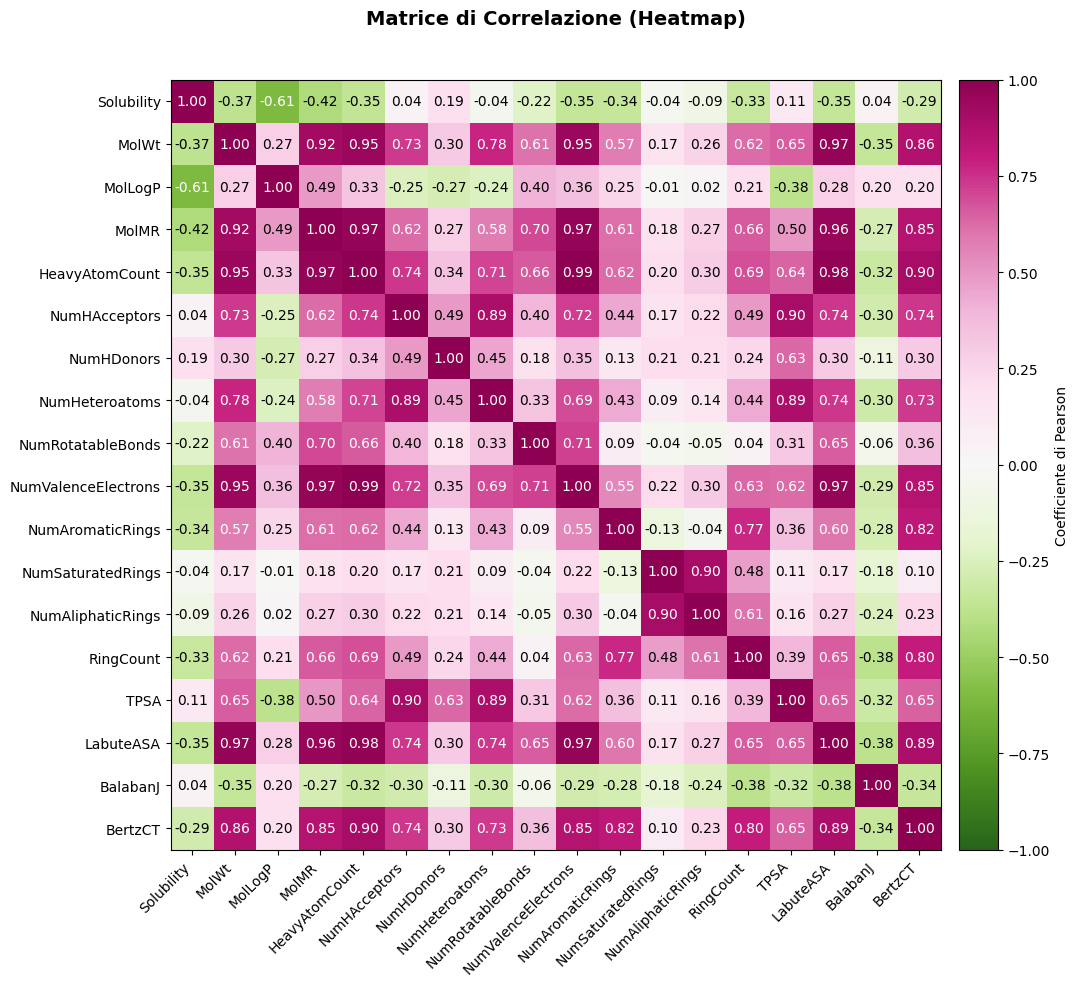

In [24]:
corr_mat = df.corr(method = "pearson")
columns = corr_mat.columns

fig,ax = plt.subplots(figsize=(12,10))

cax = ax.imshow(corr_mat.values, cmap="PiYG_r", vmin=-1, vmax=1)

ax.figure.colorbar(cax, ax=ax, label="Coefficiente di Pearson",pad=0.02)
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

for (i, j), val in np.ndenumerate(corr_mat.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
            color="white" if abs(val) > 0.5 else "black")

ax.grid(False)
plt.title("Matrice di Correlazione (Heatmap)", fontsize=14, fontweight="bold", pad=40)
plt.show()


###2.6.1 Analisi correlazione feature-feature
Dopo un'attenta analisi, vediamo che la heatmap rivela una forte correlazione tra alcuni gruppi di variabili:

> Nei riquadri rossi (esclusa la diagonale) notiamo in particolare che le variabili che descrivono a grandi linee la dimensione del composto (quindi `MolWt`, `MolMR`, `HeavyAtomCount`, `NumValenceElectrons` e `LabuteASA`) sono collegate con punteggi molto alti $r>0,9$ che segnalano una forte ridondanza.

###2.6.2 Analisi correlazione feature-target
Concentriamoci sulla colonna della matrice relativa al target `LogS`:

In [25]:
display(corr_mat['Solubility'].drop("Solubility").sort_values().round(3).to_frame(name="Pearson r"))

,Pearson r
MolLogP,-0.609
MolMR,-0.424
MolWt,-0.368
HeavyAtomCount,-0.353
LabuteASA,-0.349
NumValenceElectrons,-0.346
NumAromaticRings,-0.343
RingCount,-0.330
BertzCT,-0.289
NumRotatableBonds,-0.222


L'analisi di Pearson effettuata nel punto precedente è stata in grado di valutare le relazioni solo assumendole lineari, non cogliendo i possibili pattern più complessi tra target e feature. Il valore assoluto più grande di correlazione con il target è $0.609$, che è un valore abbastanza significativo ma che indica una relazione non puramente lineare.

Introduciamo lo Scatter Plot per verificare visivamente la forma delle distribuzioni e la presenza di vincoli strutturali.

>Prendiamo i 6 predittori con correlazione maggiore (in valore assoluto) con il target $LogS$

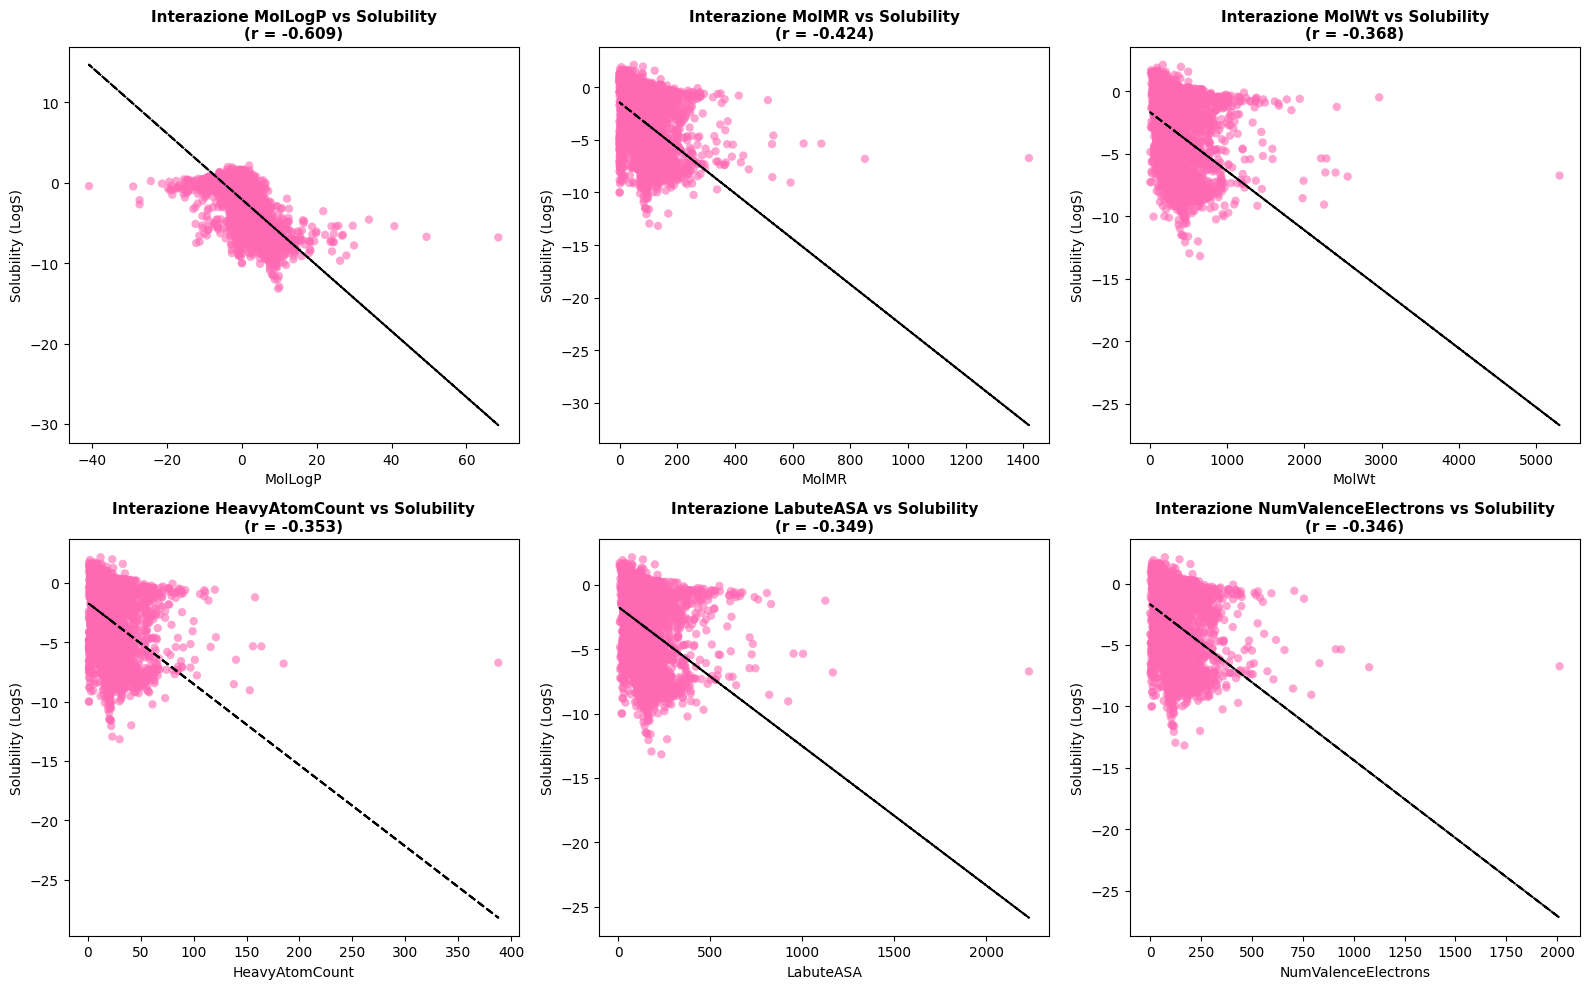

In [26]:
top_corr = corr_mat['Solubility'].abs().drop('Solubility').sort_values(ascending=False).head(6)
features_to_show = top_corr.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_show):
    scatter = axes[i].scatter(df[col], df['Solubility'], color="hotpink", alpha=0.6, edgecolors='none')

    m, q = np.polyfit(df[col], df["Solubility"], 1)
    axes[i].plot(df[col], m*df[col] + q, color="black", linestyle="--", linewidth=1.5)

    r_val = corr_mat.loc[col, 'Solubility']
    axes[i].set_title(f"Interazione {col} vs Solubility\n(r = {r_val:.3f})", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Solubility (LogS)")

plt.tight_layout()
plt.show()

Nel primo grafico possiamo notare alcuni outlier per quanto riguarda la Lipofilia:

Infatti appaiono dei punti con valori di MolLogP minori di $-20$ e maggiori di $+40$, che non sono sostenibili biologicamente e che rappresentano anomalie strutturali nel dataset.

##2.7 Analisi della Qualità e Provenienza dei Dati (Sorkun et al., 2019)
Come evidenziato nella letteratura ufficiale sul dataset AqSolDB, i dati di solubilità provengono dalla fusione di 9 sotto-dataset sperimentali differenti. Possiamo identificare la sorgente dalla lettera iniziale presente nell'ID della molecola (da A a I).

Analizziamo come si distribuiscono le istanze e se esistono differenze significative nella variabilità del target ($LogS$) a seconda della sorgente sperimentale.

In [27]:
df_init['ID'].head().to_frame() # Notiamo la prima lettera (es. "A")

,ID
0,A-3
1,A-4
2,A-5
3,A-8
4,A-9


In [114]:
df_source = df.copy()
df_source['Source'] = df_init['ID'].astype(str).str.split('-').str[0]

table_sources = df_source.groupby('Source')['Solubility'].agg(
    Tot_rows='count',
    Mean_LogS='mean',
    Standard_Deviation='std',
    Min_LogS='min',
    Max_LogS='max'
).round(3)

table_sources['Percentage_impact'] = ((table_sources['Tot_rows'] / len(df_source)) * 100).round(2).astype(str) + '%'

table_sources = table_sources.sort_values(by='Tot_rows', ascending=False)
display(table_sources)

,Tot_rows,Mean_LogS,Standard_Deviation,Min_LogS,Max_LogS,Percentage_impact
Source,,,,,,
A,3656,-2.978,2.668,-11.999,2.138,36.63%
B,3542,-2.612,2.297,-13.172,1.699,35.48%
C,1325,-3.444,2.060,-10.600,1.000,13.27%
F,798,-2.677,1.446,-8.560,1.130,7.99%
E,249,-2.586,1.836,-8.710,1.150,2.49%
D,163,-2.434,2.011,-7.456,1.558,1.63%
G,139,-3.413,2.220,-11.600,0.790,1.39%
H,64,-5.254,2.964,-12.950,-0.240,0.64%
I,46,-3.435,1.014,-6.140,-1.720,0.46%


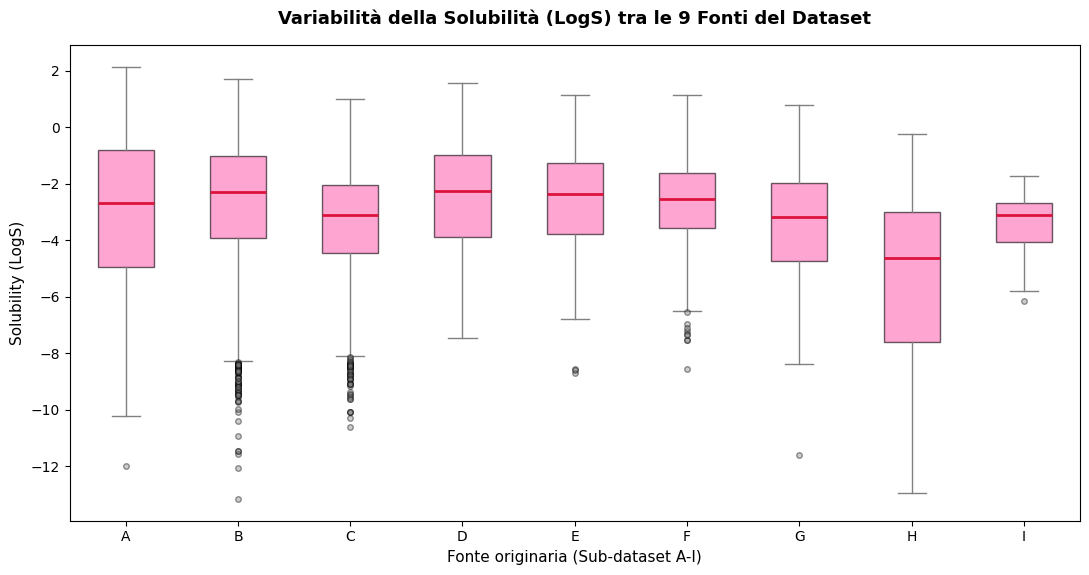

In [105]:
fig, ax = plt.subplots(figsize=(11, 6))
df_source.boxplot(column='Solubility', by='Source', ax=ax, grid=False, patch_artist=True,
           boxprops=dict(facecolor="hotpink", alpha=0.6, edgecolor="black"),
           medianprops=dict(color="crimson", linewidth=2),
           capprops=dict(color="gray"),
           whiskerprops=dict(color="gray"),
           flierprops=dict(marker='o', markerfacecolor='gray', alpha=0.4, markersize=4))

plt.title("Variabilità della Solubilità (LogS) tra le 9 Fonti del Dataset", fontsize=13, fontweight='bold', pad=15)
plt.suptitle("")
plt.xlabel("Fonte originaria (Sub-dataset A-I)", fontsize=11)
plt.ylabel("Solubility (LogS)", fontsize=11)

plt.tight_layout()
plt.show()

>L'estrazione delle 9 fonti originarie (A-I) ha confermato la presenza di sotto-dataset fortemente sbilanciati in termini di dimensione e accuratezza strumentale.

L'analisi della varianza ($SD$) misura l'eterogeneità distributiva delle sorgenti del dataset.

Per esempio vediamo che la sorgente A presenta un'impatto percentuale importante e una variabilità statistica ($SD = 2.66$) significativamente superiore alla mediana del dataset. Questo indica che la fonte A introduce un dominio di valori talmente ampio e disperso da fungere da outlier globale durante la fase di apprendimento del modello.

> In un secondo momento, ispirandosi a *Sorkun et al. (2019)*, verrà sfruttata la selezione qualitativa dei dati. Si è deciso di seguire lo sviluppo del paper ed escludere in addestramento le fonti che si sono dimostrate particolarmente rumorose, come A. Allo stesso modo, la validazione verrà effettuata sul sottogruppo E, che mostra un buon trade-off tra dimensioni limitate e deviazione standard bassa, per spingere al massimo l'accuratezza predittiva eliminando il rumore di fondo.

Questa analisi verrà ripresa nella sezione **6.** in cui si seguiranno le indicazioni e le procedure espresse dal paper, per un'ulteriore ottimizzazione della predizione.

**Per ora però procediamo con lo scenario "baseline"**:

##2.8 Conclusioni della EDA
L'analisi esplorativa ha delineato la struttura del dataset, evidenziando aspetti cruciali per la preparazione dei dati e per la scelta dei modelli:

* Si tratta di un dataset piuttosto ricco e descrittivo di 18 variabili, alcune delle quali mostrano dei gruppi di **collinearità** multipla molto alta.
> Ridondanze evidenti e intuitive come `HeavyAtomCount`, `NumValenceElectrons` e altre feature collegate al peso molecolare con punteggi di collinearità estremamente alti verranno rimossi a monte della prossima sezione. Le restanti collinearità complesse verranno preservate e delegate alla regolarizzazione automatica dei modelli predittivi.

* Sono presenti outlier molto alti, che potrebbero far pensare a errori di laboratorio e che generano code nelle distribuzioni delle feature.
> Si decide di non eliminare questi record intergalmente per garantire la massima rappresentatività dello spazio chimico. L'impatto di questi outlier sarà gestito nella preparazione dei dati e dalla robustezza dei modelli non lineari e l'uso di metriche di valutazione adeguate.

---



#**3. Preparazione dei dati**

## 3.1 Rimozione degli Outliers
Come abbiamo notato nell'EDA la distribuzione della Lipofilia ($MolLogP$) presenta valori estremi, in particolare record con valori inferiori a $-20$ o superiori a $+40$.

Tali misurazioni non sono fisicamente sostenibili e sono quindi prive di significato chimico-biologico, sono riconducibili ad anomalie strutturali nel database originale.


In [149]:
df = df[(df['MolLogP'] > -20) & (df['MolLogP'] < 40)].copy()
print(f"Dimensioni del dataset dopo la pulizia: {df.shape}")

Dimensioni del dataset dopo la pulizia: (9973, 18)


##3.2 Isolamento del target
Per prima cosa, separiamo le variabili predittive dal target quantitativo.

* **y**: rappresenta il vettore contenente la variabile target `Solubility` ($LogS$).
* **X**: rappresenta la matrice di tutti i descrittori molecolari indipendenti utilizzati come predittori.

In [150]:
X = df.drop(columns="Solubility")
y = df['Solubility']

print("Dimensioni della matrice delle feature X:", X.shape)
print("Dimensioni del vettore target y:", y.shape[0])


Dimensioni della matrice delle feature X: (9973, 17)
Dimensioni del vettore target y: 9973


## 3.3 Feature Engineering
Creiamo ora delle **nuove feature** derivate per arricchire il set informativo:
>Queste nuove feature combinano alcune delle variabili rimaste, evidenziando proprietà chimiche importanti per il processo di solubilizzazione:

1. **HD_HA_ratio (`NumHDonors` / `NumHAcceptors`):** Rappresenta il bilancio geometrico tra donatori e accettori di legami a idrogeno. Valuta la capacità della molecola di interagire con il reticolo d'acqua circostante.

2. **aromatic_fraction (`NumAromaticRings` / `RingCount`):** Esprime la frazione di anelli aromatici rispetto al totale degli anelli presenti nella struttura (o "densità aromatica"). Una frazione elevata favorisce un forte "impacchettamento" nel reticolo cristallino solido (rendendo la sostanza più difficile da solubilizzare).

3. **polar_weight_ratio (`TPSA`/`MolWt`)**: Rappresenta la superficie polare totale (TPSA) normalizzata rispetto alla massa complessiva della molecola.
Dal punto di vista chimico-fisico, una molecola piccola ma altamente polare mostrerà dinamiche di idratazione e interazione con il solvente radicalmente differenti rispetto a una macromolecola ingombrante che possiede lo stesso identico valore assoluto di TPSA, ma diluito su una struttura più grande.

In [191]:
X['HD_HA_ratio'] = X['NumHDonors'] / (X['NumHAcceptors'] + 1)
X['aromatic_density'] = X['NumAromaticRings'] / (X['RingCount'] + 1)
X['polar_weight_ratio'] = X['TPSA'] / (X['MolWt'] + 1)

print("Dimensioni di X con l'aggiunta delle nuove feature:", X.shape)
display(X[['HD_HA_ratio', 'aromatic_density', 'polar_weight_ratio']].head(5))


Dimensioni di X con l'aggiunta delle nuove feature: (9973, 20)


,HD_HA_ratio,aromatic_density,polar_weight_ratio
0,0.000000,0.000000,0.000000
1,0.500000,0.500000,0.170992
2,0.000000,0.500000,0.120577
3,0.285714,0.857143,0.159424
4,0.000000,0.285714,0.133640


##3.4 Suddivisione in Training Set e Test Set

Procediamo a dividere il dataset in due frazioni distinte:
* **Training Set (80%):** Destinato all'addestramento vero e proprio dei modelli predittivi e alla successiva ottimizzazione degli iperparametri.
* **Test Set (20%):** Mantenuto completamente isolato dal processo di addestramento, servirà valutare la reale capacità di generalizzazione dei modelli su strutture molecolari mai viste prima.


In [192]:
from sklearn.model_selection import train_test_split

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Molecole destinate all'addestramento:", X_train.shape[0])
print("Molecole destinate al test finale:", X_test.shape[0])

Molecole destinate all'addestramento: 7978
Molecole destinate al test finale: 1995


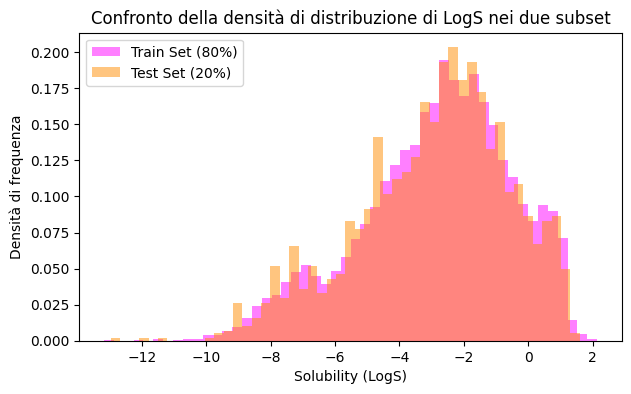

In [194]:
plt.figure(figsize=(7, 4))
plt.hist(y_train, bins=50, alpha=0.5, label='Train Set (80%)', density=True, color='magenta')
plt.hist(y_test, bins=50, alpha=0.5, label='Test Set (20%)', density=True, color='darkorange')
plt.title('Confronto della densità di distribuzione di LogS nei due subset')
plt.xlabel('Solubility (LogS)')
plt.ylabel('Densità di frequenza')
plt.legend()
plt.show()

La quasi totale identità delle due curve conferma che il processo di split casuale è stato rappresentativo:
>il modello di training avrà quindi modo di esplorare l'intero dominio delle solubilità presente nel test set, garantendo una valutazione delle prestazioni priva di bias campionari e rendendo i risultati del modello generalizzabili a nuove molecole dello stesso spazio chimico.

##3.5 Gestione delle Feature e Creazione dei Flussi Separati
Algoritmi diversi richiedono rappresentazioni dei dati differenti.

Per massimizzare le performance ed evitare di penalizzare i modelli, il preprocessing si biforca in due binari paralleli e indipendenti:

1. I modelli lineari, come la Ridge Regression, risentono fortemente della multicollinearità. Si rende necessario procedere con la rimozione della **collinearità**.

2. Gli algoritmi basati su alberi gestiscono nativamente la multicollinearità. Rimuovere feature collineari in questo caso comporterebbe solo una perdita di informazioni geometriche non lineari. Pertanto, questo flusso mantiene intatta la matrice originaria.

### 3.5.1 Preparazione Dati per modelli lineari

Come evidenziato al termine dell'analisi esplorativa, siamo in presenza di forti relazioni lineari in un particolare gruppo di predittori:
> **Rimuoviamo** le feature ripetitive nel gruppo legato al peso molecolare (`MolWt`), con collinearità maggiori di $r = 0.95$.

In [155]:
corr_mat = X_train.corr().abs() # Ricalcolo le collinearità solo su X_train per evitare data leakage
pairs = corr_mat.abs().unstack()
pairs = pairs[pairs < 1.0]

high_corr_pairs = pairs[pairs>0.95].drop_duplicates().sort_values(ascending=False)
print("Coppie di features con collinearità critica:")
high_corr_pairs.to_frame("r")

Coppie di features con collinearità critica:


r
HeavyAtomCount      NumValenceElectrons  0.992201
                    LabuteASA            0.981458
MolWt               LabuteASA            0.974735
MolMR               HeavyAtomCount       0.973179
                    NumValenceElectrons  0.971342
NumValenceElectrons LabuteASA            0.971185
MolMR               LabuteASA            0.954774
MolWt               HeavyAtomCount       0.951680

In [156]:
cols_to_drop = [pair[1] for pair in high_corr_pairs.index]
cols_to_drop = list(set(cols_to_drop))
X_train_reduced = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_reduced  = X_test.drop(columns=cols_to_drop, errors='ignore')

print("Colonne rimosse:", cols_to_drop)
print("Dimensioni di X originale:", X_train.shape)
print("Dimensioni del nuovo X_reduced:", X_train_reduced.shape)

Colonne rimosse: ['HeavyAtomCount', 'LabuteASA', 'NumValenceElectrons']
Dimensioni di X originale: (7978, 20)
Dimensioni del nuovo X_reduced: (7978, 17)


### 3.5.2 Preparazione Dati per modelli basati su alberi
Data la natura di questi modelli, utilizziamo per il loro addestramento il set originale (completo delle variabili e non scaled)


In [157]:
X_train_full = X_train.copy()
X_test_full  = X_test.copy()

#**4. Addestramento e validazione**

In questa sezione procederemo con l'addestramento e la validazione dei modelli per prevedere la solubilità delle molecole.

La sezione sarà strutturata confrontando due approcci algoritmici differenti, di cui verranno valutate le metriche di performance ($MSE$, $RMSE$, $MAE$, $MAPE$ e $R^2$).

In [195]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [196]:
results = []

def eval_model(name, y_real, y_pred):
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print("Metriche di valutazione modello:", name)
    print("MSE: ", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("MAE: ", round(mae, 4))
    print("R2:  ", round(r2, 4))

    return {
        "Modello": name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4)
    }

## **4.1 Regressione Lineare**
Per i modelli lineari, il confrontiamo la Regressione Ordinary Least Squares, la Ridge ($L_2$) e la LASSO ($L_1$) per mettere in evidenza la natura geometrica dei nostri descrittori chimici.

>* Ridge distribuisce il peso su tutte le feature macroscopiche ridotte.
>* Lasso tenta una selezione netta eliminando i coefficienti superflui.

In [202]:
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 4.1.1 Regressione Standard (OLS)

In [203]:
ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ols_pipeline.fit(X_train_reduced, y_train)
y_pred_ols = ols_pipeline.predict(X_test_reduced)
res_ols = eval_model("Linear Regression (Standard OLS)", y_test, y_pred_ols)

res_ols["Best_Alpha"] = 0.0
results.append(res_ols)

Metriche di valutazione modello: Linear Regression (Standard OLS)
MSE:  2.3859
RMSE: 1.5446
MAE:  1.1646
R2:   0.5744


### 4.1.2 Ridge Regression

In [204]:
alphas_to_test = np.logspace(-6, -2, 50)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas = alphas_to_test, cv=5, scoring='r2'))
])

ridge_pipeline.fit(X_train_reduced, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test_reduced)
best_alpha_ridge = ridge_pipeline.named_steps['model'].alpha_

res_ridge = eval_model("Ridge Regression (Pipeline)", y_test, y_pred_ridge)
print("Miglior Alpha trovato da Ridge:", best_alpha_ridge)

res_ridge["Best_Alpha"] = round(best_alpha_ridge, 4)
results.append(res_ridge)

Metriche di valutazione modello: Ridge Regression (Pipeline)
MSE:  2.3859
RMSE: 1.5446
MAE:  1.1646
R2:   0.5744
Miglior Alpha trovato da Ridge: 0.01


### 4.1.3 LASSO Regression

In [205]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas = alphas_to_test, cv=5, max_iter=10000, random_state=42))
])

lasso_pipeline.fit(X_train_reduced, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test_reduced)
best_alpha_lasso = lasso_pipeline.named_steps['model'].alpha_

res_lasso = eval_model("LASSO Regression (Pipeline)", y_test, y_pred_lasso)
print("Miglior Alpha trovato da LASSO:", best_alpha_lasso.round(4))

res_lasso["Best_Alpha"] = round(best_alpha_lasso, 4)
results.append(res_lasso)

Metriche di valutazione modello: LASSO Regression (Pipeline)
MSE:  2.3827
RMSE: 1.5436
MAE:  1.1645
R2:   0.575
Miglior Alpha trovato da LASSO: 0.0047


In [206]:
df_linear_results = pd.DataFrame(results)
display(df_linear_results)

,Modello,MSE,RMSE,MAE,R2,Best_Alpha
0,Linear Regression (Standard OLS),2.3859,1.5446,1.1646,0.5744,0.0000
1,Ridge Regression (Pipeline),2.3859,1.5446,1.1646,0.5744,0.0100
2,LASSO Regression (Pipeline),2.3827,1.5436,1.1645,0.5750,0.0047
3,Linear Regression (Standard OLS),2.3859,1.5446,1.1646,0.5744,0.0000
4,Ridge Regression (Pipeline),2.3859,1.5446,1.1646,0.5744,0.0100
5,LASSO Regression (Pipeline),2.3827,1.5436,1.1645,0.5750,0.0047


#### **Conclusioni**:
L'analisi comparativa dei modelli lineari ha mostrato che, a differenza della Regressione Ridge e del metodo OLS, le cui performance risultano abbastanza sovrapponibili, la LASSO Regression ha ottenuto le prestazioni migliori ($R^2 = 0.575$ e $RMSE = 1.5436$).

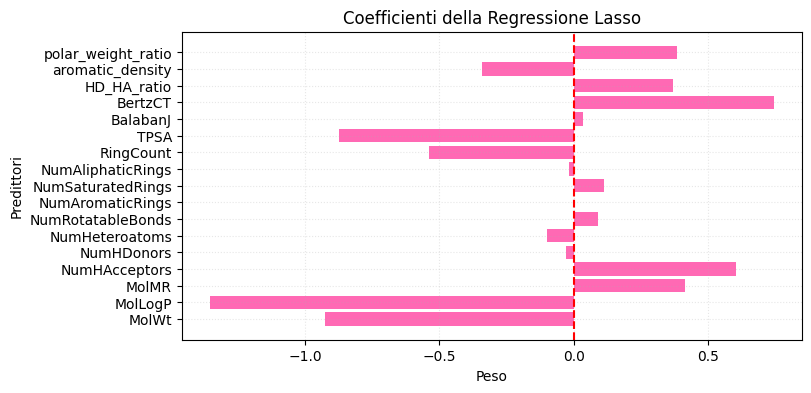

In [207]:
coef_lasso = lasso_pipeline.named_steps['model'].coef_

plt.figure(figsize=(8, 4))
plt.barh(X_train_reduced.columns, coef_lasso, color='hotpink')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Coefficienti della Regressione Lasso')
plt.xlabel('Peso')
plt.ylabel('Predittori')
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()

Notiamo i predittori che più incidono sulla solubilità molecolare:
> **Coefficienti Negativi:**
   * `MolLogP` (~ -1.4) e `MolWt` (~ -0.9) mostrano i coefficienti negativi più impattanti. Questo è biologicamente coerente, infatti le molecole molto idrofobiche (con alto $LogP$) e con alto meso molecolare incontrano una forte resistenza alla solubilizzazione in un solvente polare come l'acqua.

> **Coefficienti Positivi**
   * `BertzCT` (~ +0.7) e `NumHAcceptors` (~ +0.6) esercitano l'influenza positiva più forte. L'alto valore dei legami accettori di idrogeno indica che la molecola è in grado di formare ponti a idrogeno con l'acqua e quindi è un indicatore della sua propensione a solubilizzarsi.

### **Plot della feature più rilevante nella OLS Regression**:

Come abbiamo visto dal grafico dei coefficienti, la feature predominante è `MolLogP`.

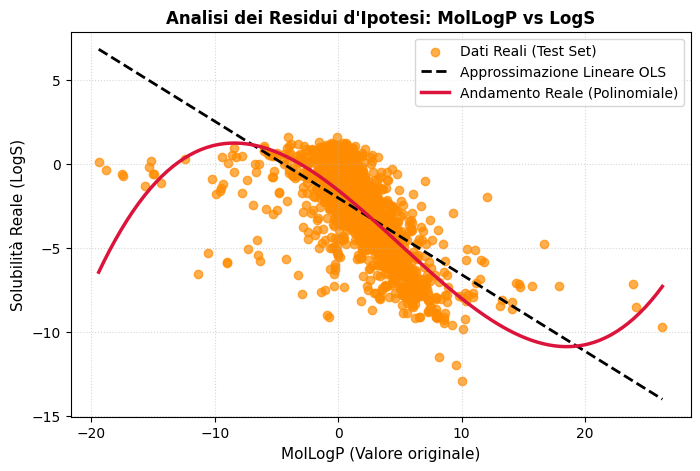

In [208]:
x_vals = X_test_reduced['MolLogP']
y_vals = y_test.values

plt.figure(figsize=(8, 5))
plt.scatter(x_vals, y_vals, alpha=0.7, color='darkorange', label='Dati Reali (Test Set)')

m, q = np.polyfit(x_vals, y_vals, 1)
x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
plt.plot(x_range, m * x_range + q, color='black', linewidth=2, linestyle='--',
         label='Approssimazione Lineare OLS')

poly_coefs = np.polyfit(x_vals, y_vals, 3)
poly_curve = np.polyval(poly_coefs, x_range)
plt.plot(x_range, poly_curve, color='crimson', linewidth=2.5,
         label='Andamento Reale (Polinomiale)')

plt.title("Analisi dei Residui d'Ipotesi: MolLogP vs LogS", fontsize=12, fontweight='bold')
plt.xlabel("MolLogP (Valore originale)", fontsize=11)
plt.ylabel("Solubilità Reale (LogS)", fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

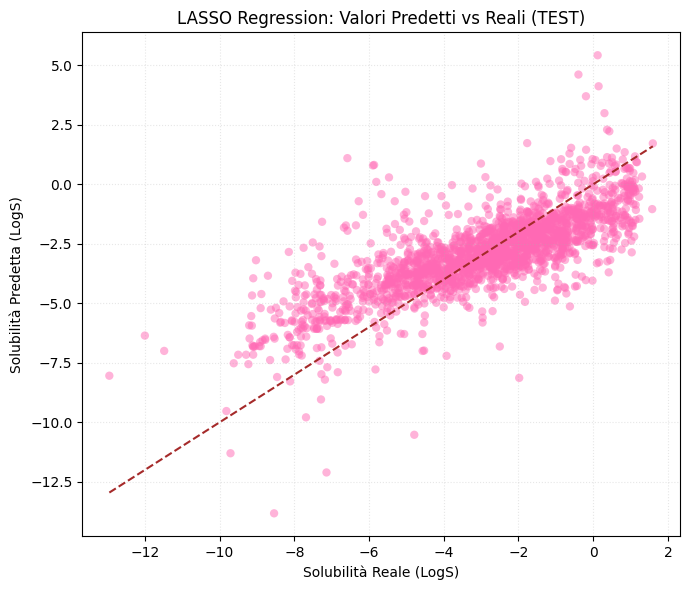

In [209]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lasso, color='hotpink', alpha=0.5, edgecolor='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='brown', linestyle='--', linewidth=1.5)

plt.title('LASSO Regression: Valori Predetti vs Reali (TEST)')
plt.xlabel('Solubilità Reale (LogS)')
plt.ylabel('Solubilità Predetta (LogS)')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

Lo scatter plot confronta i valori reali di solubilità presenti nel Test Set con i valori predetti dal modello.

>La linea tratteggiata rappresenta la "predizione ideale" ( y=x ).

Per superare il limite strutturale, nella prossima sezione si abbandonerà l'ipotesi di linearità per introdurre modelli non lineari basati su alberi di decisione (come **Random Forest** e **XGBoost**).


---



## **4.2 Regressione tramite Alberi Decisionali**
In questa sezione verranno valutati i *Tree-based Methods*. L'obiettivo è stabilire una nuova baseline predittiva sfruttando tre algoritmi incrementali:
1. **Decision Tree Regressor:** Un modello a singolo albero, fondamentale per l'ispezione visiva delle regole di split e l'interpretabilità logica dei primi livelli decisionali.
2. **Random Forest Regressor:** Algoritmo di *Bagging* che riduce drasticamente la varianza intrinseca del singolo albero mediando le predizioni di un ensemble di alberi indipendenti.
3. **XGBoost Regressor (Extreme Gradient Boosting):** Algoritmo di *Boosting* sequenziale che ottimizza l'errore attraverso la discesa del gradiente.

In [174]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

### 4.2.1 Decision Tree

In [175]:
dt_model = DecisionTreeRegressor(random_state=42)

In [176]:
dt_model.fit(X_train_full, y_train)

DecisionTreeRegressor(random_state=42)

In [177]:
y_pred_dt = dt_model.predict(X_test_full)
res_dt = eval_model("Decision Tree (Baseline)", y_test, y_pred_dt) # iperparametri di default
res_dt["Best_Alpha"] = "N/A"
results.append(res_dt)

Metriche di valutazione modello: Decision Tree (Baseline)
MSE:  2.4696
RMSE: 1.5715
MAE:  1.0258
R2:   0.5595


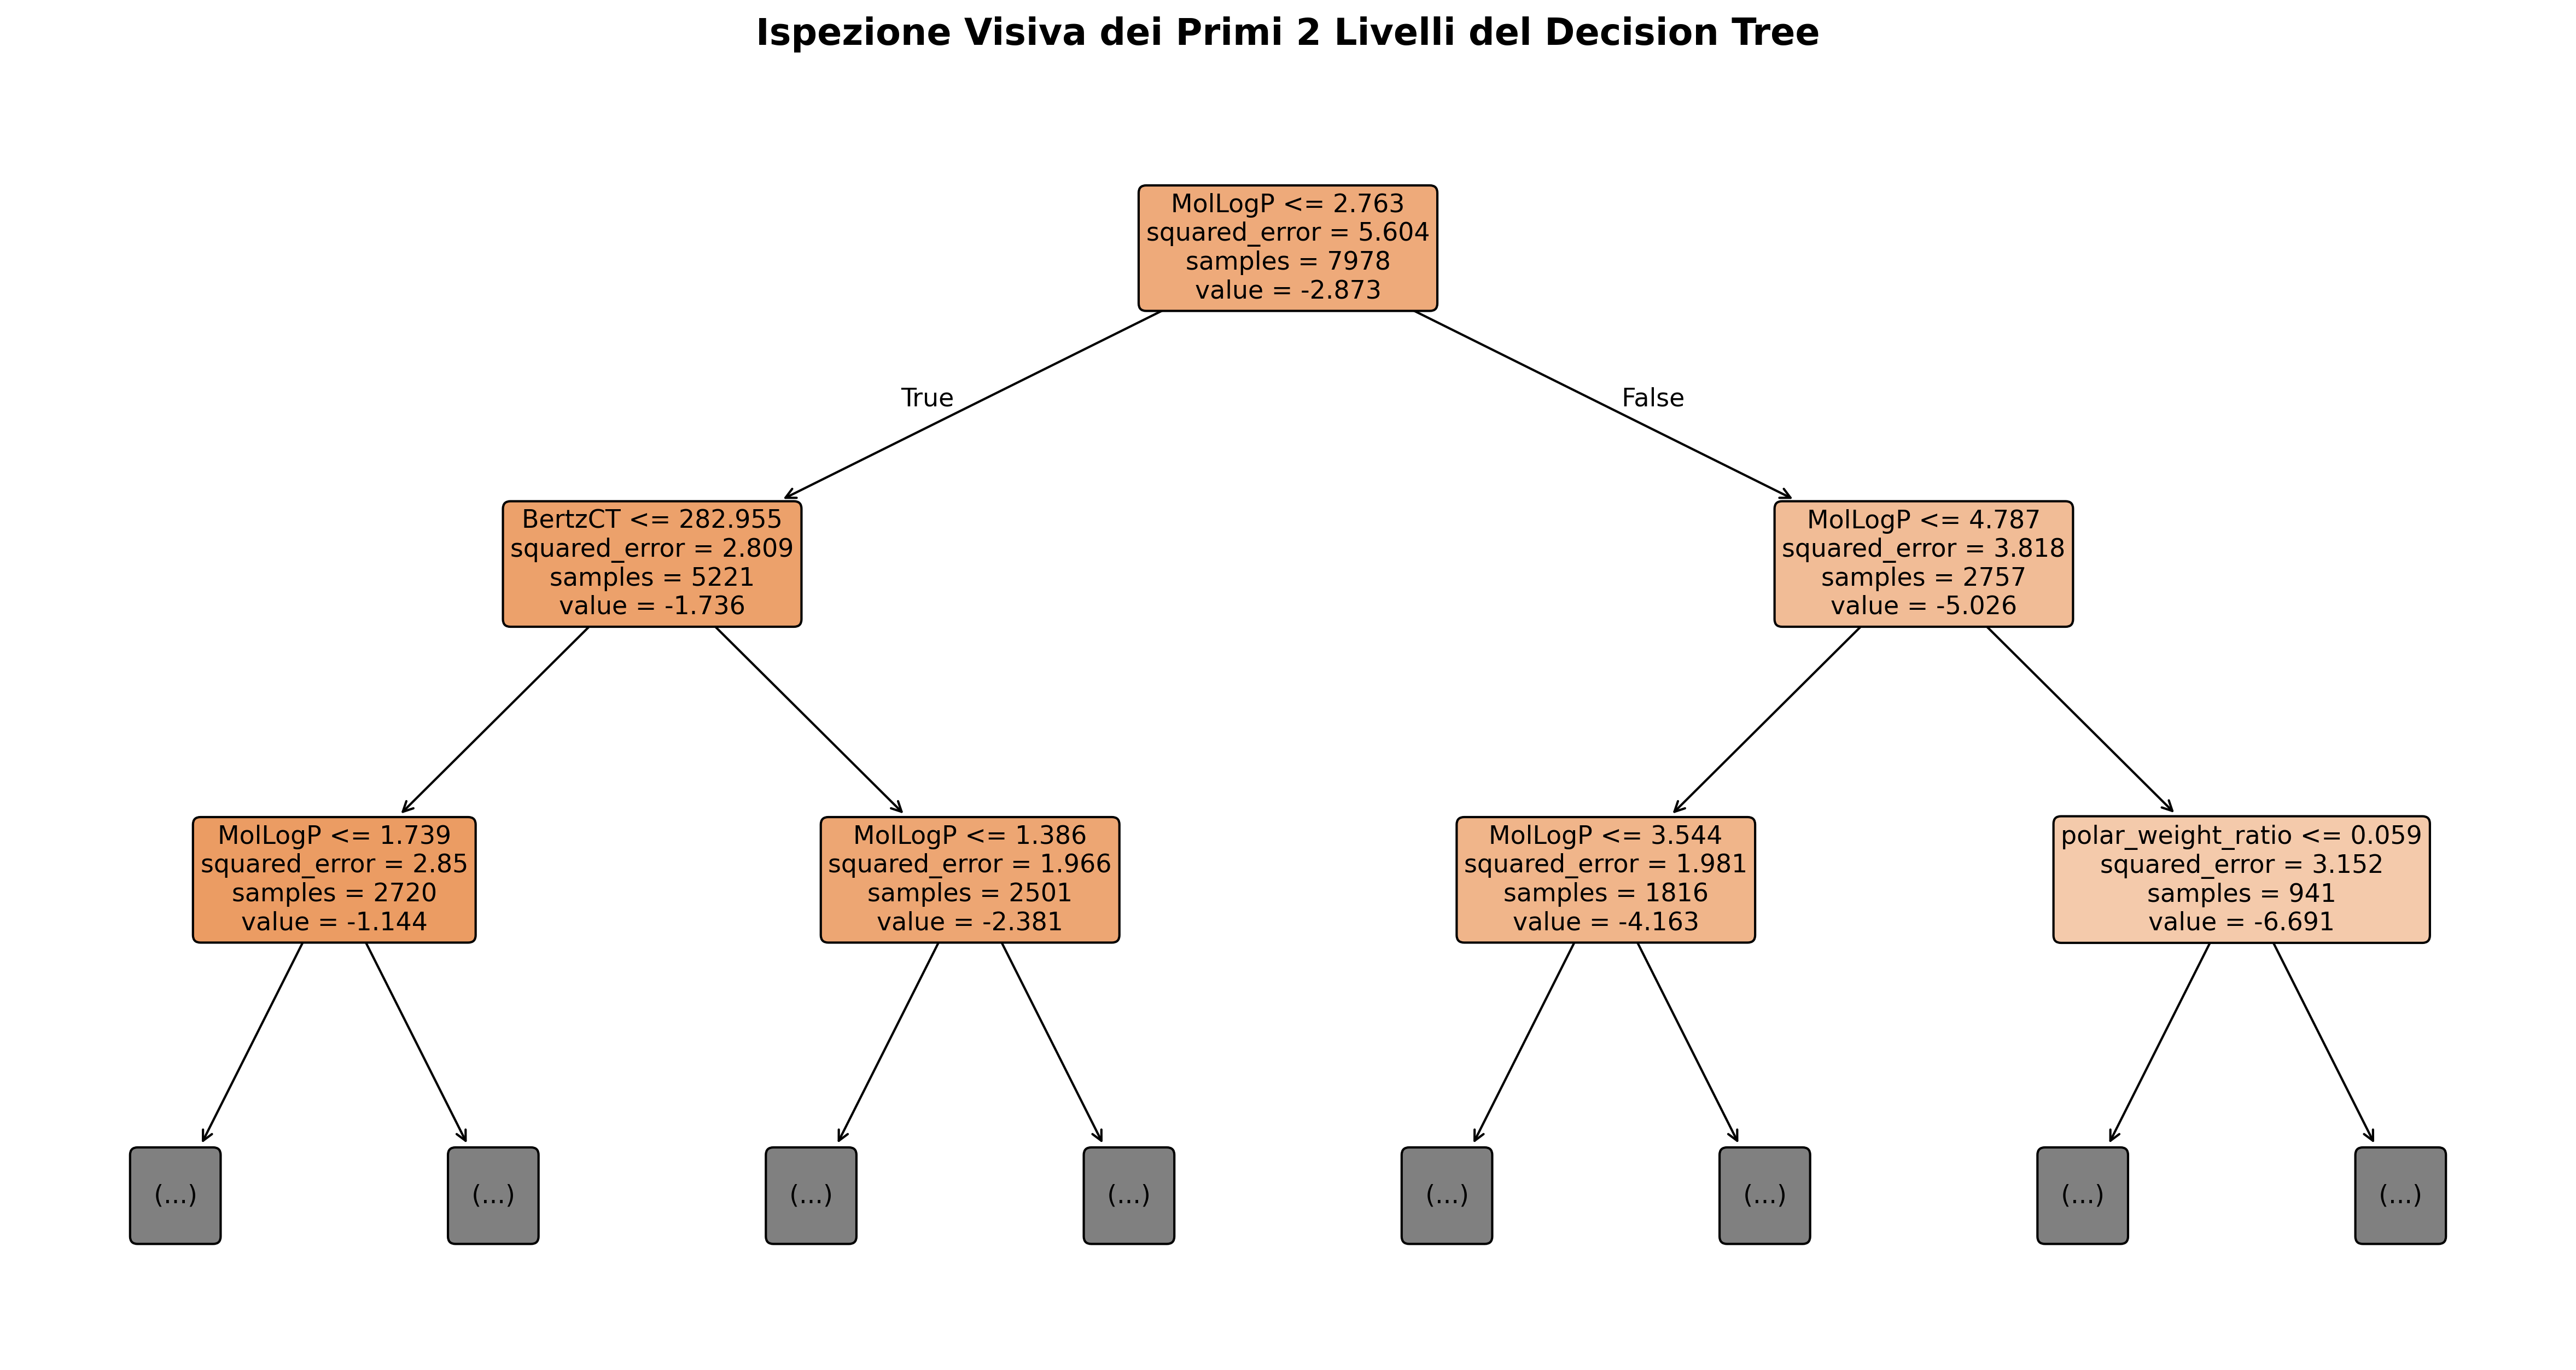

In [178]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    dt_model,
    max_depth=2,
    feature_names=X_train_full.columns,
    filled=True,
    rounded=True,
    fontsize=11,
    precision=3
)

plt.title("Ispezione Visiva dei Primi 2 Livelli del Decision Tree", fontsize=16, fontweight='bold', pad=20)
plt.show()

Questa struttura gerarchica dimostra chiaramente perché i modelli lineari (OLS, Ridge, LASSO) non siano stati in grado di superare la barriera del 55% di varianza spiegata.

>L'albero dimostra, per esempio, che il peso molecolare (`MolWt`) è cruciale **solo se** la molecola è altamente idrofila ($MolLogP \le 1.564$), mentre perde rilevanza nei composti fortemente apolari, dove governano i fattori geometrici (`BalabanJ`).

I metodi basati su alberi catturano queste interazioni condizionali non lineari e non costanti in modo nativo.

Abbiamo inoltre già un'idea di quali saranno le **feature di maggiore importanza**:

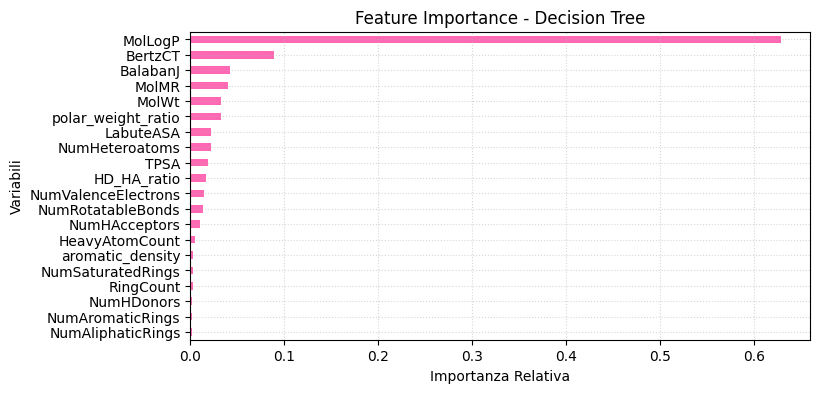

In [179]:
dt_importance = pd.Series(dt_model.feature_importances_, index = X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
dt_importance.plot(kind='barh', color='hotpink')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importanza Relativa')
plt.ylabel('Variabili')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### **Scatter plot delle predizioni**

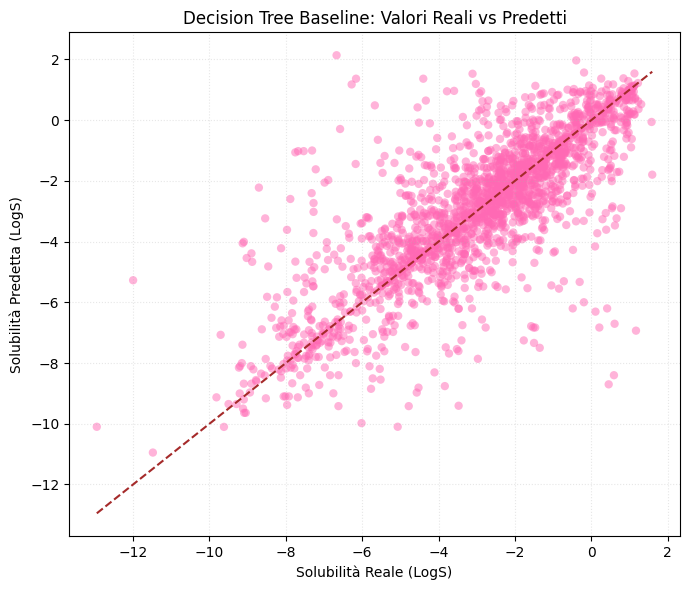

In [180]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_dt, color='hotpink', alpha=0.5, edgecolor='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='brown', linestyle='--', linewidth=1.5)

plt.title('Decision Tree Baseline: Valori Reali vs Predetti')
plt.xlabel('Solubilità Reale (LogS)')
plt.ylabel('Solubilità Predetta (LogS)')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

La nuvola di punti si distribuisce in modo costante lungo la diagonale in modo abbastanza simmetrico, superando le performance della regressione lineare.

Notiamo comunque che è presente una notevole disperisione dei punti.

In [181]:
print("Profondità massima raggiunta dall'albero baseline:", dt_model.get_depth())
print("Numero totale di nodi foglia:", dt_model.get_n_leaves())

Profondità massima raggiunta dall'albero baseline: 32
Numero totale di nodi foglia: 7647


Considerando che l'intero subset di addestramento ($X_{train}$) è composto da 7985 osservazioni, la generazione di 7672 nodi terminali indica che il modello ha raggiunto un rapporto molecole/foglie prossimo a **1:1**.
L'albero è cresciuto fino alla quasi totale purezza dei nodi, frammentando lo spazio delle feature fino a isolare e memorizzare le singole strutture molecolari.

Una profondità pari a 38 implica che il modello soffre di un'altissima **Varianza**: l'algoritmo ha modellato il rumore sperimentale e le fluttuazioni marginali dei descrittori chimici presenti nel Training Set.
Le capacità del modello di generalizzazione sul Test Set saranno fortemente penalizzate dall'instabilità strutturale dei rami più profondi.

>Introduciamo quindi i modelli di *ensamble*, come la **Random Forest**.

### 4.2.2 Random Forest
Il secondo modello *tree-based* che andiamo ad analizzare è il Random Forest Regressor, basato su un modello di *ensemble*.

Invece di affidarsi a un singolo albero di decisione, per evitare overfitting, vengono interpellati diversi alberi, ciascuno addestrato su una partizione casuale del dataset.

In [217]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

In [218]:
rf_model.fit(X_train_full, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [219]:
y_pred_rf = rf_model.predict(X_test_full)
res_rf = eval_model("Random Forest (Baseline)", y_test, y_pred_rf)
res_rf["Best_Alpha"] = "N/A"
results.append(res_rf)

Metriche di valutazione modello: Random Forest (Baseline)
MSE:  1.2415
RMSE: 1.1142
MAE:  0.7562
R2:   0.7786


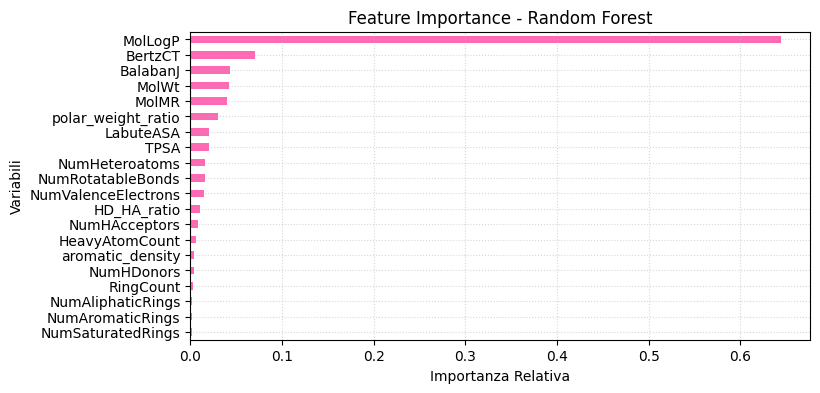

In [220]:
rf_importance = pd.Series(rf_model.feature_importances_, index = X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
rf_importance.plot(kind='barh', color='hotpink')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importanza Relativa')
plt.ylabel('Variabili')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Tramite il grafo della feature importance possiamo analizzare l'apporto di ciascun descrittore nella riduzione dell'errore globale (MSE).

Vediamo ancora che il descrittore con maggiore "dominanza" è chiaramente `MolLogP` (con circa il $65$% dell'importanza totale). Rappresenta di fatto la "macro-tendenza" maggiore utilizzata dal modello per guidare la predizione.



### **Scatter plot delle predizioni**

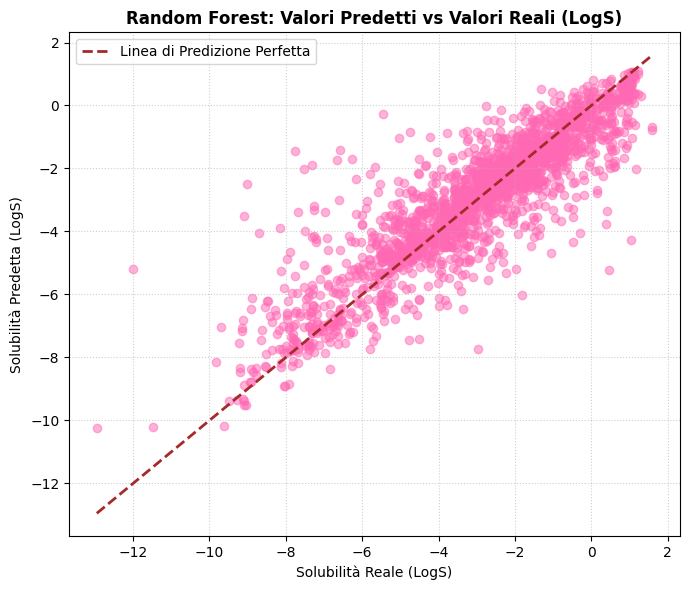

In [186]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='hotpink')
ideal_line = [y_test.min(), y_test.max()]
plt.plot(ideal_line, ideal_line, color='brown', linestyle='--', linewidth=2, label='Linea di Predizione Perfetta')

plt.title('Random Forest: Valori Predetti vs Valori Reali (LogS)', fontsize=12, fontweight='bold')
plt.xlabel('Solubilità Reale (LogS)')
plt.ylabel('Solubilità Predetta (LogS)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Vediamo il vero salto della qualità rispetto ai modelli precedenti.
La nuvola di punti è molto meno sparsa di quella del decision tree singolo, e il valore di $R^2$ sul Test Set sale fino a $R^2 = 0.7853$.
Il modello riesce quindi a "spiegare" circa il 78% della variabilità della solubilità molecolare.

### 4.2.3 XGBoost
Anch'esso è basato su un'*ensemble* di alberi di decisione, ma a differenza del Random Forest non addestra gli alberi in modo parallelo e indipendente ma tramite una successione sequenziale.

Ogni albero viene costruito per "correggere" gli errori residui dei precedenti.

In [210]:
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

In [211]:
xgb_model.fit(X_train_full, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [212]:
y_pred_xgb = xgb_model.predict(X_test_full)
res_xgb = eval_model("XGBoost (Baseline)", y_test, y_pred_xgb)
res_xgb["Best_Alpha"] = "N/A"
results.append(res_xgb)

Metriche di valutazione modello: XGBoost (Baseline)
MSE:  1.3248
RMSE: 1.151
MAE:  0.7804
R2:   0.7637


Il valore di $R^2$ del XGBoost con parametri di default mostra delle performance simili, ma leggermente inferiori, a Random Forest, con un punteggio di $0.771$.
Si tratta comunque di un valore molto alto rispetto ai modelli lineari e al singolo Decision Tree.

### **Scatter plot delle predizioni**

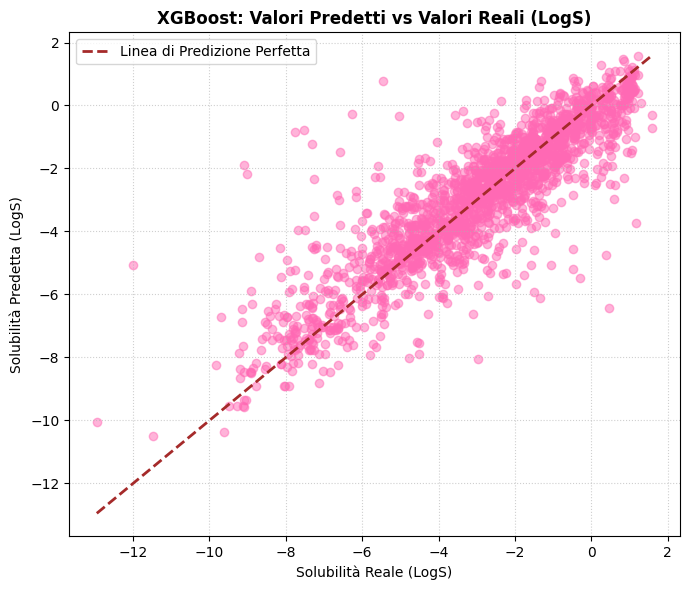

In [213]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='hotpink')
ideal_line = [y_test.min(), y_test.max()]
plt.plot(ideal_line, ideal_line, color='brown', linestyle='--', linewidth=2, label='Linea di Predizione Perfetta')

plt.title('XGBoost: Valori Predetti vs Valori Reali (LogS)', fontsize=12, fontweight='bold')
plt.xlabel('Solubilità Reale (LogS)')
plt.ylabel('Solubilità Predetta (LogS)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

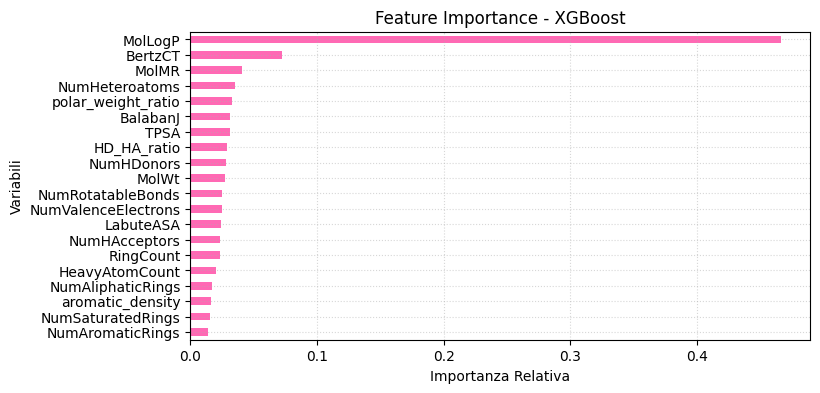

In [214]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index = X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
xgb_importance.plot(kind='barh', color='hotpink')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importanza Relativa')
plt.ylabel('Variabili')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Il confronto tra questo grafico e quello della Random Forest evidenzia una forte coerenza di fondo tra i due modelli non lineari.

Entrambi identificano la Lipofilia (MolLogP) come il descrittore chimico dominante in assoluto per determinare la solubilità (LogS).

La divergenza principale risiede nella distribuzione dei pesi secondari. Il XGB distribuisce l'importanza in modo più omogeneo sulle altre variabili.
Random Forest, al contrario, concentra quasi tutto il potere predittivo su MolLogP.

## 4.3 Confronto finale tra i modelli

Raccogliamo le performance dei tre modelli in una tabella comparativa
e visualizziamo graficamente le differenze su MSE, RMSE, MAE e R².
Infine confrontiamo visivamente le 3 predizioni con i valori reali
tramite il grafico Predicted vs Actual.

In [215]:
results_df = pd.DataFrame(results).set_index("Modello")
print("CONFRONTO PERFORMANCE SUL TEST SET:\n")
display(results_df.round(4))

CONFRONTO PERFORMANCE SUL TEST SET:



,MSE,RMSE,MAE,R2,Best_Alpha
Modello,,,,,
Linear Regression (Standard OLS),2.3859,1.5446,1.1646,0.5744,0.0
Ridge Regression (Pipeline),2.3859,1.5446,1.1646,0.5744,0.01
LASSO Regression (Pipeline),2.3827,1.5436,1.1645,0.5750,0.0047
Linear Regression (Standard OLS),2.3859,1.5446,1.1646,0.5744,0.0
Ridge Regression (Pipeline),2.3859,1.5446,1.1646,0.5744,0.01
LASSO Regression (Pipeline),2.3827,1.5436,1.1645,0.5750,0.0047
XGBoost (Baseline),1.3248,1.1510,0.7804,0.7637,N/A


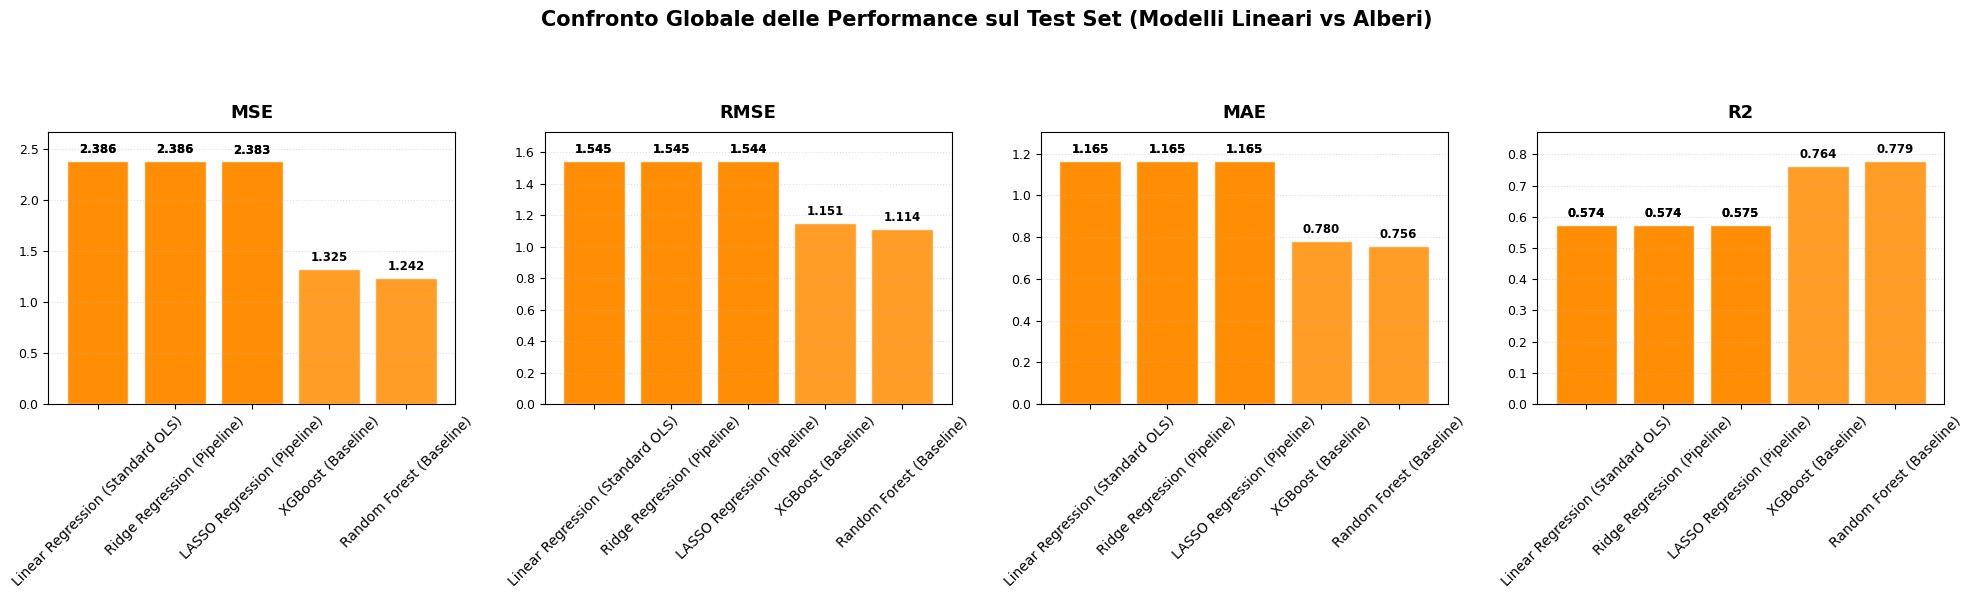

In [221]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_df = pd.DataFrame(results)
metrics = ['MSE', 'RMSE', 'MAE', 'R2']

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5.5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    val = results_df[metric].astype(float)
    bars = ax.bar(results_df['Modello'], val, color="darkorange", edgecolor="white", alpha=0.85)
    ax.set_title(metric, fontweight="bold", fontsize=13, pad=10)

    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=9)

    ax.grid(axis='y', linestyle=':', alpha=0.4)
    max_val = val.max()
    offset = max_val * 0.02

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold"
        )
    ax.set_ylim(0, max_val + (offset * 6))

plt.suptitle("Confronto Globale delle Performance sul Test Set (Modelli Lineari vs Alberi)",
             fontsize=15, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

### **Confronto tra gli scatter plot di LASSO, Random Forest e XGB**:

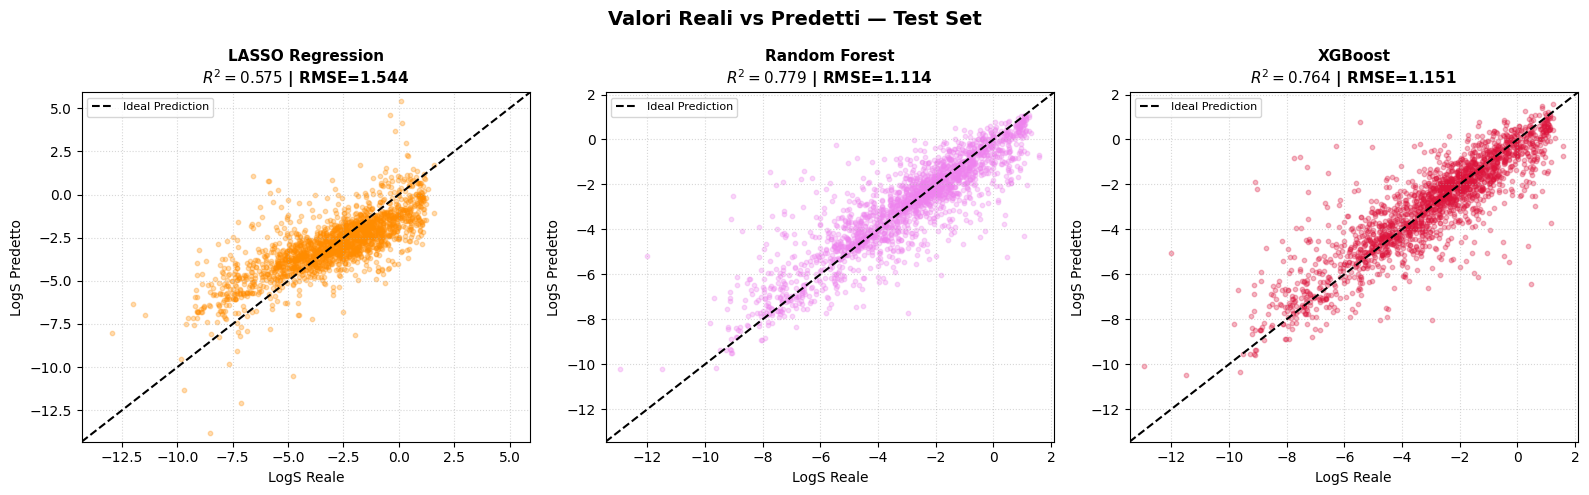

In [222]:
models_map ={
    "LASSO Regression": (y_pred_lasso, "darkorange"),
    "Random Forest": (y_pred_rf, "violet"),
    "XGBoost": (y_pred_xgb, "crimson")
}

fig, axes = plt.subplots(1,3, figsize=(16,5))

for ax, (name, (y_pred, col)) in zip (axes, models_map.items()):

  lim = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
  ax.scatter(y_test, y_pred, alpha=0.3, s=10, color= col)
  ax.plot(lim, lim, "k--", linewidth=1.5, label="Ideal Prediction")

  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))

  ax.set_title(f"{name}\n$R^2={r2:.3f}$ | RMSE={rmse:.3f}", fontweight="bold", fontsize=11)
  ax.set(xlim=lim, ylim=lim, xlabel="LogS Reale", ylabel="LogS Predetto")
  ax.legend(fontsize=8, loc='upper left')
  ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Valori Reali vs Predetti — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#**5. Ricerca degli iper-parametri**

Dopo aver confrontato le performance di base dei modelli nella sezione **4.**, il passo successivo è l'**ottimizzazione degli iperparametri** dei modelli *tree-based*.
Questo processo mira a trovare un equilibrio tra la tendenza all'overfitting e la over-semplificazione.

Ogni algoritmo richiede una strategia di tuning specifica, basata sulla sua architettura:

* **Random Forest:** il tuning mira a controllare la crescita dei singoli alberi per evitarne la specializzazione eccessiva sul training set (***overfitting***). Si prenderranno in considerazione iperparametri strutturali come profondità massima e `min_sample_leaf`.
* **XGBoost:** Trattandosi di un modello di gradient boosting sequenziale, il rischio principale è l'overfitting rapido. Il tuning si focalizzerà sul bilanciamento tra la `max_depth` dell'albero e il *learning rate* ($η$).

In [223]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from scipy.stats           import uniform, randint

## 5.1 Tuning della Random Forest
Nei modelli basati su alberi decisionali l'ottimizzazione si concentra sul controllo della complessità geometrica delle strutture.

### Tipi di iperparametri su cui intervenire:
1. **Iperparametri dell'Ensemble (La Foresta):**
* `n_estimators`: Definisce il numero di alberi indipendenti. Un numero maggiore riduce l'errore stabilizzando la varianza, a fronte di un costo computazionale più alto.
* `max_features`: Controlla la strategia di randomizzazione, stabilendo quante variabili considerare casualmente ad ogni split per garantire la diversificazione degli alberi.

2. **Iperparametri dei singoli Alberi:**
* `max_depth`: Limita la profondità massima di crescita di ciascun albero per evitare la specializzazione eccessiva sui dati di addestramento.
* `min_samples_leaf`: Rappresenta il numero minimo di istanze (molecole) richieste per formare una foglia. Impedisce la creazione di nodi troppo specifici che memorizzerebbero singoli campioni del training set.

* `min_samples_split`: Indica il numero minimo di campioni per dividere un nodo. Se questi sono alti portano ad alberi più semplici e con meno overfitting.

In [70]:
param_dist_rf = {
    "n_estimators"     : randint(100, 350),
    "max_depth"        : [4, 6, 8, 10, 15, 20, None],
    "min_samples_split": randint(2, 12),
    "min_samples_leaf" : randint(1, 6),
    "max_features"     : ["sqrt", "log2", 0.5, 0.7]
}

rf_cv = RandomizedSearchCV(
    estimator          = RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions= param_dist_rf,
    n_iter             = 60,
    cv                 = 5,
    scoring            = "r2",
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

rf_cv.fit(X_train_full, y_train)

print("Migliori iperparametri trovati:")
df_params = pd.Series(rf_cv.best_params_).to_frame(name='Valore Ottimizzato')
df_params.index.name = 'Iperparametro'
display(df_params)
print("R2 medio di Cross-Validation:", rf_cv.best_score_.round(4))
print("R2 finale sul TEST SET dopo il tuning:", round(rf_cv.score(X_test_full, y_test), 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Migliori iperparametri trovati:


,Valore Ottimizzato
Iperparametro,
max_depth,NaN
max_features,0.5
min_samples_leaf,1.0
min_samples_split,5.0
n_estimators,212.0


R2 medio di Cross-Validation: 0.7746
R2 finale sul TEST SET dopo il tuning: 0.7897


## 5.2 Tuning del XGBoost

XGBoost adotta una strategia sequenziale di costruzione degli alberi, in cui ogni nuovo stimatore viene addestrato con l'obiettivo di correggere gli errori residui commessi dagli alberi precedenti (*Boosting*).

A causa di questa struttura, XGBoost con parametri di default tende a soffrire di overfitting.

### Tipi di parametri su cui intervenire:

* `learning_rate`: Scala il contributo di ciascun nuovo albero (*shrinkage*). Un valore più piccolo costringe il modello ad apprendere in modo più lento e conservativo, impedendo a un singolo albero di dominare la predizione e migliorando la stabilità complessiva.

* `max_depth`: Limita l'altezza di ciascun albero.

* `subsample`: Definisce la frazione di molecole (righe) estratta casualmente per l'addestramento di ogni albero.

* `colsample_bytree`: Definisce la frazione di descrittori chimici (colonne) da considerare ad ogni split. Questa doppia randomizzazione introduce variabilità artificiale, riducendo la correlazione tra gli alberi sequenziali.

* `gamma` ($\gamma$): Rappresenta la soglia minima di guadagno (Gain) richiesta per effettuare uno split aggiuntivo lungo il ramo. Se una ramificazione non produce un incremento informativo superiore a $\gamma$, la crescita viene interrotta o il ramo viene rimosso tramite un processo di post-potatura, impedendo al modello di isolare singole molecole o accogliere rumore di fondo.

* `reg_lambda` ($\lambda$): Controlla la regolarizzazione L2 sui coefficienti di regressione (pesi) all'interno delle foglie. L'inclusione di una severa penalizzazione L2 permette di smorzare i valori predittivi troppo estremi generati dagli alberi profondi, neutralizzando l'effetto distorcente derivante dalle fluttuazioni e dal rumore sperimentale intrinseco nei dati biologici di partenza.





In [71]:
param_dist_xgb = {
    "n_estimators"     : randint(200, 600),
    "max_depth"        : randint(3, 8),
    "learning_rate"    : uniform(0.01, 0.19),
    "subsample"        : uniform(0.6, 0.4),
    "colsample_bytree" : uniform(0.6, 0.4),
    "reg_alpha"        : uniform(0, 2),
    "reg_lambda"       : uniform(0, 2),
    "min_child_weight" : randint(1, 8),
    "gamma"            : uniform(0, 0.5)
}

xgb_cv = RandomizedSearchCV(
    estimator          = XGBRegressor(
                             random_state = 42,
                             n_jobs       = 1,
                             verbosity    = 0,
                             objective    = "reg:squarederror"
                         ),
    param_distributions= param_dist_xgb,
    n_iter             = 100,
    cv                 = 5,
    scoring            = "r2",
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)


xgb_cv.fit(X_train_full, y_train)

print("Migliori iperparametri trovati:")
df_params = pd.Series(xgb_cv.best_params_).to_frame(name='Valore Ottimizzato')
df_params.index.name = 'Iperparametro'
display(df_params)
print("R2 medio di Cross-Validation:", round(xgb_cv.best_score_, 4))
print("R2 finale sul TEST SET dopo il tuning:", round(xgb_cv.score(X_test_full, y_test), 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Migliori iperparametri trovati:


,Valore Ottimizzato
Iperparametro,
colsample_bytree,0.729020
gamma,0.424335
learning_rate,0.035958
max_depth,7.000000
min_child_weight,2.000000
n_estimators,446.000000
reg_alpha,0.839562
reg_lambda,0.512414
subsample,0.844605


R2 medio di Cross-Validation: 0.7765
R2 finale sul TEST SET dopo il tuning: 0.7869


## 5.4 Confronto tra modelli post-tuning

In questa sezione viene presentato il confronto conclusivo tra le performance di tutti gli algoritmi di Machine Learning sviluppati nello studio.

L'obiettivo è identificare lo stimatore ottimale della solubilità acquoda $LogS$ e analizzare come le diverse architetture abbiano risposto alle caratteristiche del dataset.

Vengono prese come metriche di riferimento per la comparazione $R^2$, il coefficiente di determinazione e $MSE$, l'errore quadratico medio.

In [72]:
if 'Modello' in results_df.columns:
    results_baseline = results_df.set_index('Modello')
else:
    results_baseline = results_df.copy()

modelli_opt = [
    ("Random Forest", rf_cv, X_test_full),
    ("XGBoost",       xgb_cv, X_test_full),
]

risultati_opt = []
for nome, model, X_t in modelli_opt:
    y_pred = model.predict(X_t)
    name_baseline = f"{nome} (Baseline)"

    r2_base = float(results_baseline.loc[name_baseline, "R2"])
    rmse_base = float(results_baseline.loc[name_baseline, "RMSE"])

    r2_opt = round(r2_score(y_test, y_pred), 4)
    rmse_opt = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)

    risultati_opt.append({
        "Model": nome,
        "R2_base": round(r2_base, 4),
        "R2_opt": r2_opt,
        "R2_Diff": round(r2_opt - r2_base, 4),
        "RMSE_base": round(rmse_base, 4),
        "RMSE_opt": rmse_opt,
        "RMSE_Diff": round(rmse_opt - rmse_base, 4)
    })

opt_df = pd.DataFrame(risultati_opt).set_index("Model")
display(opt_df)

,R2_base,R2_opt,R2_Diff,RMSE_base,RMSE_opt,RMSE_Diff
Model,,,,,,
Random Forest,0.7853,0.7897,0.0044,1.0792,1.0682,-0.0110
XGBoost,0.7710,0.7869,0.0159,1.1146,1.0751,-0.0395


## Analisi dei risultati post-tuning

Il tuning conferma le performance attese per entrambi i modelli.

>**Random Forest** mostra un miglioramento marginale ($ΔR^2 = +0.003$):
il modello base era già vicino al suo ottimo su questo dataset.
La struttura ensemble con bagging garantisce naturalmente una buona
regolarizzazione, rendendo i parametri di default già ragionevoli.

>**XGBoost** beneficia maggiormente del tuning ($ΔR^2 = +0.016$):
i parametri di default non erano altrettanto ottimali per questo problema.
L'introduzione di *gamma* come soglia di pruning e l'aumento dello
spazio di ricerca hanno permesso di trovare una configurazione
più adatta alla struttura non lineare dei dati molecolari.

I due modelli ottimizzati convergono a $R^2 ≈ 0.788$ (con una
differenza di $0.0016$ che figura Random Forest come più accurata). Su questo dataset, Random Forest e XGBoost ottimizzato
rappresentano soluzioni equivalenti.

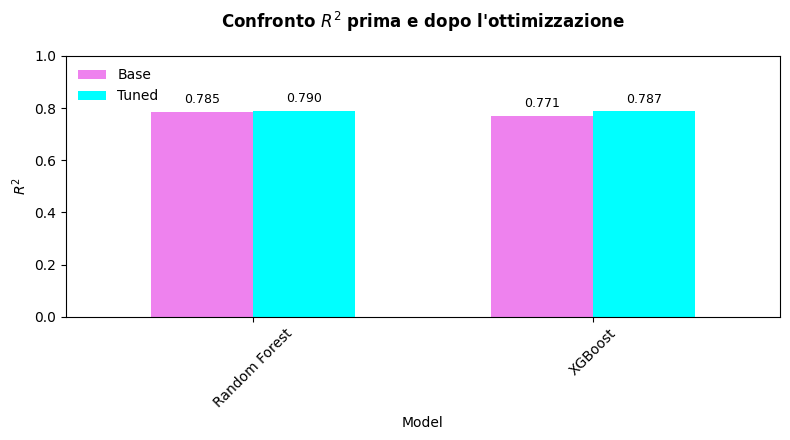

In [73]:
ax = opt_df[['R2_base', 'R2_opt']].plot(
    kind='bar',
    figsize=(8, 4.5),
    color=['violet', 'cyan'],
    width=0.6
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=9, color='black')

ax.tick_params(axis='x', rotation=45)

ax.set_ylim(0, 1.0)
ax.set_ylabel("$R^2$", fontsize=10)

ax.set_title("Confronto $R^2$ prima e dopo l'ottimizzazione", fontsize=12, fontweight="bold", pad=20)
ax.legend(["Base", "Tuned"], frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

# Approccio basato su *Sorkun et al. (2021)*

In questa sezione finale, eleviamo la qualità del progetto seguendo l'approccio ***Data-Centric*** dal lavoro di *Sorkun et al. (2021)* per il modello *AqSolPred*.

Come abbiamo osservato nella nostra EDA (Sezione 2.7), il rumore sperimentale intrinseco delle diverse fonti blocca le performance dei modelli tradizionali intorno a un $R^2 \approx 0.78$. Per superare questo limite, implementeremo tre strategie chiave in scala ridotta:
1. **Filtrazione dei Dati (Set "non-A"):** Escluderemo dal training set il sotto-dataset sperimentale **A** (caratterizzato da un'elevata deviazione standard dell'errore rispetto al numero di righe).
2. **Test Set Bilanciato (Set "E"):** Valuteremo i modelli esclusivamente sul sotto-dataset **E**, poiché ha una deviazione standard abbastanza ridotta e presenta un appropriato numero di righe.
3. **Modello di *Consensus*:** Combineremo le predizioni dei nostri due modelli migliori (Random Forest e XGBoost, precedentemente ottimizzati) tramite una media matematica per correggere i rispettivi bias sistematici.

In [127]:
train_groups = ['B', 'C', 'D', 'F', 'G', 'H', 'I']
test_group = ['E']

df_train_cleaned = df_source[df_source['Source'].isin(train_groups)]
df_test_cleaned = df_source[df_source['Source'].isin(test_group)]

X_train_final = df_train_cleaned.drop(columns=['ID', 'Source', 'Solubility'], errors='ignore')
y_train_final = df_train_cleaned['Solubility']

X_test_final = df_test_cleaned.drop(columns=['ID', 'Source', 'Solubility'], errors='ignore')
y_test_final = df_test_cleaned['Solubility']

print("Training Set 'non-A' dimensioni:", X_train_final.shape)
print("Test Set 'E' dimensioni:", X_test_final.shape)

Training Set 'non-A' dimensioni: (6077, 17)
Test Set 'E' dimensioni: (249, 17)


In [128]:
rf_final = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_final, y_train_final)
xgb_final = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train_final, y_train_final)

y_pred_rf = rf_final.predict(X_test_final)
y_pred_xgb = xgb_final.predict(X_test_final)

y_pred_consensus = (y_pred_rf + y_pred_xgb) / 2

print("R2 finale del modello di Consensus sul TEST SET:", round(r2_score(y_test_final, y_pred_consensus), 4))
print("RMSE finale del modello di Consensus sul TEST SET:", round(np.sqrt(mean_squared_error(y_test_final, y_pred_consensus)), 4))

R2 finale del modello di Consensus sul TEST SET: 0.9098
RMSE finale del modello di Consensus sul TEST SET: 0.5501


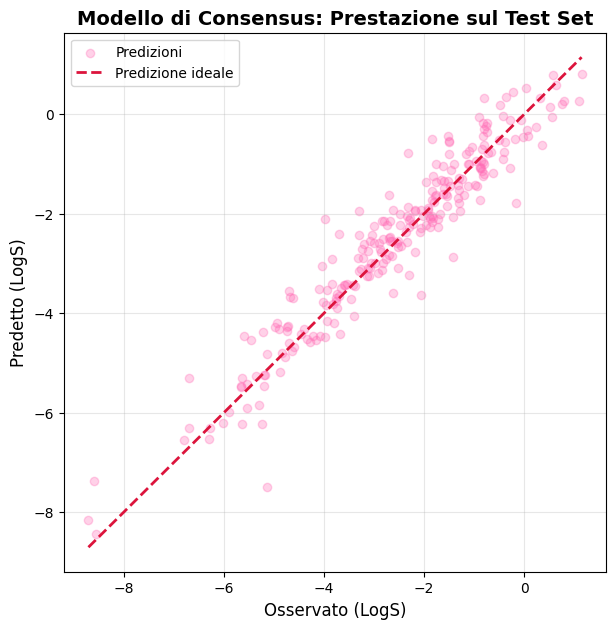

In [147]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_final, y_pred_consensus, alpha=0.3, color='hotpink', label='Predizioni')
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()],
         color='crimson', lw=2, linestyle='--', label='Predizione ideale')

plt.xlabel('Osservato (LogS)', fontsize=12)
plt.ylabel('Predetto (LogS)', fontsize=12)
plt.title('Modello di Consensus: Prestazione sul Test Set', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Riferimenti
Per lo sviluppo di questo progetto è stato utilizzato il dataset ufficiale e la metodologia di riferimento descritti nella seguente pubblicazione scientifica:

>Sorkun, M. C., Sharma, A., Kavirani, A. F., & Koelman, J. M. V. A. (2019). AqSolDB, a curated reference dataset for aqueous solubility and 2D descriptor database. *Scientific Data*, 6(1), 176.
  [https://doi.org/10.1038/s41597-019-0151-1](https://www.nature.com/articles/s41597-019-0151-1)